# 00_prepare_data

In [130]:
import json, time
from pathlib import Path
import sys
from pandas.io.parquet import to_parquet

sys.path.append("../..")  # adjust if needed

from src.config import DATA_PROCESSED, DATA_RAW, RANDOM_SEED
from src.data_loading import load_cohort_table

# Hardcode the paths instead of using argparse in a notebook
DATA_PATH   = DATA_RAW / "clean_dat.csv"
OUTPUT_DIR  = DATA_PROCESSED
SEED        = RANDOM_SEED

print(f"Data path : {DATA_PATH}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Seed      : {SEED}")
print(f"Data file exists: {DATA_PATH.exists()}")


Data path : /Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics/data/raw/clean_dat.csv
Output dir: /Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics/data/processed
Seed      : 42
Data file exists: True


In [ ]:
start = time.time()


cohort_table, protein_ids, audit = load_cohort_table(DATA_PATH)

print(f"Loaded in {time.time() - start:.2f}s")
print(f"\ncohort_table type : {type(cohort_table)}")
print(f"cohort_table shape: {cohort_table.shape}")
print(f"\nFirst 3 rows:")
cohort_table.head(3)

/Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics/src/data_loading.py:181: DtypeWarning: Columns (13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(data_path)


Loaded in 5.31s

cohort_table type : <class 'pandas.core.frame.DataFrame'>
cohort_table shape: (408, 10778)

First 3 rows:


,patient_id,seq.10000.28,seq.10001.7,seq.10003.15,seq.10006.25,seq.10008.43,seq.10010.10,seq.10011.65,seq.10012.5,seq.10014.31,...,seq.9986.14,seq.9987.30,seq.9989.12,seq.9991.112,seq.9993.11,seq.9994.217,seq.9995.6,seq.9997.12,seq.9999.1,y
0,1922111017,2.598134,2.538825,1.990339,2.666143,2.520090,2.426999,3.099266,3.022923,2.902166,...,3.556206,2.376029,2.723948,2.476976,2.950267,3.104521,3.439743,4.385402,3.112001,0
1,1922110614,2.588496,2.490099,2.073718,2.922674,2.476976,2.384353,3.125774,2.889077,2.884569,...,3.247163,2.339054,2.744919,2.629919,2.874482,3.162923,3.325064,4.197049,3.213039,0
2,1922120418,2.616790,2.575880,2.357554,2.773348,2.545060,2.383277,3.105408,2.902112,3.269349,...,3.401676,2.318689,2.752663,2.443889,2.924899,3.098332,4.029014,4.588454,3.314668,0


: 

: 

: 

: 

: 

In [ ]:
print(f"protein_ids type : {type(protein_ids)}")
print(f"protein_ids count: {len(protein_ids)}")
print(f"First 5 IDs      : {protein_ids[:5]}")

print("\naudit keys and values:")
for k, v in audit.items():
    print(f"  {k}: {v}")

protein_ids type : <class 'list'>
protein_ids count: 10776
First 5 IDs      : ['seq.10000.28', 'seq.10001.7', 'seq.10003.15', 'seq.10006.25', 'seq.10008.43']

audit keys and values:
  rows_input: 1449
  dropped_missing_sepsis_or_ards: 960
  dropped_non_sepsis: 72
  kept_sepsis_no_ards: 343
  dropped_missing_or_conflicting_severity: 0
  dropped_mild_ards: 9
  kept_sepsis_not_mild_ards: 65
  patient_id_source: SubjectID
  rows_output: 408
  n_proteins: 10776


: 

: 

: 

: 

: 

In [ ]:
n_patients   = len(cohort_table)
n_proteins   = len(protein_ids)
n_ards       = int(cohort_table["y"].sum())
prevalence   = n_ards / n_patients if n_patients else 0.0

print("=== Cohort summary ===")
print(f"  Patients        : {n_patients}")
print(f"  Protein features: {n_proteins}")
print(f"  ARDS positives  : {n_ards}  ({100*prevalence:.1f}%)")
print(f"  ARDS negatives  : {n_patients - n_ards}")

print("\n--- target column (y) value counts ---")
print(cohort_table["y"].value_counts())

=== Cohort summary ===
  Patients        : 408
  Protein features: 10776
  ARDS positives  : 65  (15.9%)
  ARDS negatives  : 343

--- target column (y) value counts ---
y
0    343
1     65
Name: count, dtype: int64


: 

: 

: 

: 

: 

In [ ]:
dropped_reasons = [
    ("missing Sepsis or ARDS label",   audit.get("dropped_missing_sepsis_or_ards", 0)),
    ("non-sepsis",                     audit.get("dropped_non_sepsis",            0)),
    ("mild ARDS",                      audit.get("dropped_mild_ards",             0)),
    ("missing/conflicting severity",   audit.get("dropped_missing_or_conflicting_severity", 0)),
]

total_dropped = sum(c for _, c in dropped_reasons)
print(f"Total patients dropped: {total_dropped}")
for reason, count in dropped_reasons:
    flag = " ← !" if count > 0 else ""
    print(f"  {count:3d}  dropped – {reason}{flag}")

print(f"\nKept breakdown:")
print(f"  sepsis, no ARDS      : {audit.get('kept_sepsis_no_ards', 0)}")
print(f"  sepsis, not-mild ARDS: {audit.get('kept_sepsis_not_mild_ards', 0)}")

Total patients dropped: 1041
  960  dropped – missing Sepsis or ARDS label ← !
   72  dropped – non-sepsis ← !
    9  dropped – mild ARDS ← !
    0  dropped – missing/conflicting severity

Kept breakdown:
  sepsis, no ARDS      : 343
  sepsis, not-mild ARDS: 65


: 

: 

: 

: 

: 

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cohort_out   = OUTPUT_DIR / "cohort.parquet"
proteins_out = OUTPUT_DIR / "protein_ids.json"

cohort_table.to_parquet(cohort_out, index=False)
with proteins_out.open("w", encoding="utf-8") as f:
    json.dump(protein_ids, f, indent=2)

print(f"cohort.parquet    : {cohort_out}  ({cohort_out.stat().st_size / 1024:.1f} KB)")
print(f"protein_ids.json  : {proteins_out}  ({proteins_out.stat().st_size / 1024:.1f} KB)")
print(f"\nFiles written successfully: {cohort_out.exists() and proteins_out.exists()}")

cohort.parquet    : /Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics/data/processed/cohort.parquet  (43577.1 KB)
protein_ids.json  : /Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics/data/processed/protein_ids.json  (184.8 KB)

Files written successfully: True


: 

: 

: 

: 

: 

# 01_generate_splits

In [ ]:
import json, pickle, time
import numpy as np
import pandas as pd
import sys
from pathlib import Path

sys.path.append("../..")

from src.config import DATA_PROCESSED, K_SPLITS, K_SPLITS_EXPENSIVE, RANDOM_SEED, TEST_SIZE
from src.splits import generate_splits

COHORT_PATH = DATA_PROCESSED / "cohort.parquet"
N_SPLITS    = K_SPLITS
SEED        = RANDOM_SEED

print(f"Cohort path : {COHORT_PATH}")
print(f"File exists : {COHORT_PATH.exists()}")
print(f"n_splits    : {N_SPLITS}")
print(f"test_size   : {TEST_SIZE}")
print(f"seed        : {SEED}")

Cohort path : /Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics/data/processed/cohort.parquet
File exists : True
n_splits    : 50
test_size   : 0.2
seed        : 42


: 

In [ ]:
cohort = pd.read_parquet(COHORT_PATH)

print(f"cohort shape: {cohort.shape}")
print(f"columns     : {list(cohort.columns[:5])} ...")
print(f"\n'y' in columns: {'y' in cohort.columns}")

y = cohort["y"].to_numpy(dtype=int)

print(f"\ny type  : {type(y)}")
print(f"y shape : {y.shape}")
print(f"y values: {y[:10]} ...")

cohort shape: (408, 10778)
columns     : ['patient_id', 'seq.10000.28', 'seq.10001.7', 'seq.10003.15', 'seq.10006.25'] ...

'y' in columns: True

y type  : <class 'numpy.ndarray'>
y shape : (408,)
y values: [0 0 0 0 0 0 0 0 0 0] ...


: 

: 

: 

: 

In [ ]:
unique_labels = np.unique(y)

print(f"Unique values in y: {unique_labels}")
print(f"All labels are 0 or 1: {np.all(np.isin(unique_labels, [0, 1]))}")
print(f"\nClass counts:")
print(f"  ARDS negative (0): {int((y == 0).sum())}")
print(f"  ARDS positive (1): {int((y == 1).sum())}")
print(f"  Prevalence       : {y.mean()*100:.1f}%")

Unique values in y: [0 1]
All labels are 0 or 1: True

Class counts:
  ARDS negative (0): 343
  ARDS positive (1): 65
  Prevalence       : 15.9%


: 

: 

: 

: 

Type of splits : <class 'list'>
Number of splits: 50
[(array([291, 133, 219, 230, 216, 280, 323,  29, 287, 364, 167, 351, 175,
       242, 239,  10, 238, 319, 140,  76,  23, 138,  32, 298, 261, 271,
       247, 345,  19,  70, 210, 248, 405, 316, 326,  75, 403, 115,  16,
       255, 159, 125, 324,  55, 123,  90, 372, 124, 265,  72,  30, 224,
        86, 196, 400,  63, 398, 395, 286, 213, 373, 180, 359, 116, 336,
        31,   2, 305, 194, 131, 290, 314, 331,  35, 320, 322, 234,  84,
         8,  33,  45, 260, 356, 155, 283, 284, 119, 245, 137, 361, 307,
       311, 186, 228,  24, 297, 113,  82, 171, 177, 109, 268,  73, 327,
       147,  44,   9, 274, 391, 333,   4,  62, 148,  60, 325, 346,  98,
       218,  39, 302, 292, 388, 275, 246, 332,  64, 199, 200,  12, 338,
       165, 350, 170, 358, 229, 407,   0, 374, 164, 156, 150, 253, 249,
       285, 114, 267, 168,  46,   7, 279, 375, 135, 310,  69, 178, 139,
       126, 117, 108, 220, 256, 182, 144, 304, 107, 195, 122, 370,  14,
       22

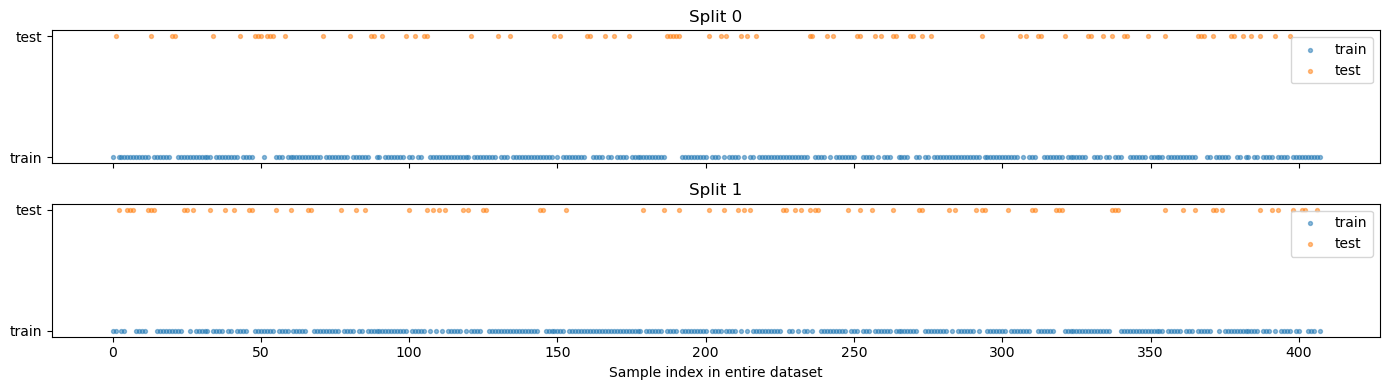

: 

: 

: 

: 

In [ ]:
import matplotlib.pyplot as plt
splits = generate_splits(
    y=y,
    k=N_SPLITS,
    test_size=TEST_SIZE,
    seed=SEED,
)

total_n = len(y)
print(f"Type of splits : {type(splits)}")
print(f"Number of splits: {len(splits)}")
print(splits)

train_idx, test_idx = splits[0]
print(f"\nSplit 0 (first one):")
print(f"  train indices shape: {train_idx.shape}  → {len(train_idx)} patients")
print(f"  test  indices shape: {test_idx.shape}   → {len(test_idx)} patients")
print(f"  first 5 train idx  : {train_idx[:5]}")
print(f"  first 5 test  idx  : {test_idx[:5]}")

for i, (train_idx, test_idx) in enumerate(splits): 
    y_train = y[train_idx]
    y_test = y[test_idx]

    train_counts = np.bincount(y_train.astype(int), minlength=2)
    test_counts = np.bincount(y_test.astype(int), minlength=2)
    train_frac = len(train_idx) / total_n
    test_frac = len(test_idx) / total_n

    print(f"\nSplit {i}:")
    print(f"  train size: {len(train_idx)} / {total_n} ({train_frac:.1%})")
    print(f"  test  size: {len(test_idx)} / {total_n} ({test_frac:.1%})")
    print(f"  train label 0/1: {train_counts[0]} / {train_counts[1]}")
    print(f"  test  label 0/1: {test_counts[0]} / {test_counts[1]}")

print(f"Type of splits : {type(splits)}")
print(f"Number of splits: {len(splits)}")



# Plot how two splits are chosen from the entire dataset
fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
for ax, (train_idx, test_idx), split_name in zip(axes, splits[:2], ["Split 0", "Split 1"]):
    ax.scatter(train_idx, np.zeros_like(train_idx), s=8, alpha=0.5, label="train")
    ax.scatter(test_idx, np.ones_like(test_idx), s=8, alpha=0.5, label="test")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["train", "test"])
    ax.set_title(split_name)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Sample index in entire dataset")
plt.tight_layout()
plt.show()

In [ ]:
n_ards_per_fold = [int(y[test_idx].sum()) for _, test_idx in splits]
n_test_per_fold = [int(test_idx.size)    for _, test_idx in splits]
prev_per_fold   = [n / t for n, t in zip(n_ards_per_fold, n_test_per_fold)]

print("fold  test_n  ards_n  prevalence")
print("----  ------  ------  ----------")
for i, (n_test, n_ards, prev) in enumerate(zip(n_test_per_fold, n_ards_per_fold, prev_per_fold)):
    print(f"  {i:02d}    {n_test:3d}     {n_ards:3d}    {prev:.3f}")

prev_arr = np.array(prev_per_fold)
print(f"\nPrevalence across folds:")
print(f"  min   : {prev_arr.min():.3f}")
print(f"  median: {np.median(prev_arr):.3f}")
print(f"  max   : {prev_arr.max():.3f}")
print(f"\n→ Tight range = stratification worked correctly")

fold  test_n  ards_n  prevalence
----  ------  ------  ----------
  00     82      13    0.159
  01     82      13    0.159
  02     82      13    0.159
  03     82      13    0.159
  04     82      13    0.159
  05     82      13    0.159
  06     82      13    0.159
  07     82      13    0.159
  08     82      13    0.159
  09     82      13    0.159
  10     82      13    0.159
  11     82      13    0.159
  12     82      13    0.159
  13     82      13    0.159
  14     82      13    0.159
  15     82      13    0.159
  16     82      13    0.159
  17     82      13    0.159
  18     82      13    0.159
  19     82      13    0.159
  20     82      13    0.159
  21     82      13    0.159
  22     82      13    0.159
  23     82      13    0.159
  24     82      13    0.159
  25     82      13    0.159
  26     82      13    0.159
  27     82      13    0.159
  28     82      13    0.159
  29     82      13    0.159
  30     82      13    0.159
  31     82      13    0.159
  32  

: 

: 

: 

: 

In [ ]:
# splits.pkl  — binary file, not printable, just confirm it saves
# splits_meta.json — human-readable summary, printed below instead

OUTPUT_DIR = DATA_PROCESSED
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

splits_path = OUTPUT_DIR / "splits.pkl"
meta_path   = OUTPUT_DIR / "splits_meta.json"

with splits_path.open("wb") as f:
    pickle.dump(splits, f, protocol=pickle.HIGHEST_PROTOCOL)

# Instead of writing meta to file, just print it here
meta = {
    "seed": SEED, "k_splits": N_SPLITS, "test_size": TEST_SIZE,
    "n_samples": int(y.size), "n_ards_total": int(y.sum()),
    "n_ards_per_test_fold": n_ards_per_fold,
    "n_test_per_fold": n_test_per_fold,
    "test_prevalence_per_fold": [round(p, 4) for p in prev_per_fold],
}
print(json.dumps(meta, indent=2))
print(f"\nsplits.pkl saved: {splits_path.exists()}")

{
  "seed": 42,
  "k_splits": 50,
  "test_size": 0.2,
  "n_samples": 408,
  "n_ards_total": 65,
  "n_ards_per_test_fold": [
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13,
    13
  ],
  "n_test_per_fold": [
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82,
    82
  ],
  "test_prevalence_per_fold": [
    0.1585,
 

: 

: 

: 

: 

# 02_run_selection.py

In [ ]:
import argparse, json, time
import numpy as np
import pandas as pd
import sys
from pathlib import Path

sys.path.append("../..")

from src.config import DATA_PROCESSED, K_SPLITS, RANDOM_SEED, RESULTS_DIR, TOPK_VALUES
from src.data_loading import load_cohort_parquet
from src.selection import METHOD_REGISTRY, validate_selection_output
from src.splits import load_splits
from src.stability import compute_stability

METHOD      = "ttest"   # byt till metoden du vill köra
N_SPLITS    = K_SPLITS
SEED        = RANDOM_SEED
COHORT_PATH = DATA_PROCESSED / "cohort.parquet"
SPLITS_PATH = DATA_PROCESSED / "splits.pkl"

print(f"Method      : {METHOD}")
print(f"n_splits    : {N_SPLITS}")
print(f"Seed        : {SEED}")
print(f"Tillgängliga metoder: {sorted(METHOD_REGISTRY.keys())}")

/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Method      : ttest
n_splits    : 50
Seed        : 42
Tillgängliga metoder: ['mi', 'random', 'rf_shap', 'ttest']


: 

In [ ]:
X, y, protein_ids = load_cohort_parquet(COHORT_PATH)
splits = load_splits(SPLITS_PATH)[:N_SPLITS]

n_samples, n_proteins = X.shape

print(f"X shape      : {X.shape}  (patienter × proteiner)")
print(f"y shape      : {y.shape}")
print(f"protein_ids  : {protein_ids[:5]} ...")
print(f"Antal splits : {len(splits)}")
print(f"Prevalence   : {y.mean()*100:.1f}%")

train_idx, test_idx = splits[0]
print(f"\nSplit 0 — train: {len(train_idx)} pat, test: {len(test_idx)} pat")

X shape      : (408, 10776)  (patienter × proteiner)
y shape      : (408,)
protein_ids  : ['seq.10000.28' 'seq.10001.7' 'seq.10003.15' 'seq.10006.25' 'seq.10008.43'] ...
Antal splits : 50
Prevalence   : 15.9%

Split 0 — train: 326 pat, test: 82 pat


: 

: 

: 

In [ ]:
args = argparse.Namespace(
    method=METHOD, seed=SEED, random_significant=30, full_data=False
)

method = METHOD_REGISTRY[METHOD](args)

print(f"Metodnamn : {method.name}")
print(f"Parametrar: {method.get_params()}")

Metodnamn : ttest
Parametrar: {'q_threshold': 0.05}


: 

: 

: 

In [ ]:
chunks = []
significant_counts = []
start_time = time.time()

for split_id, (train_idx, _) in enumerate(splits):
    split_seed = SEED + split_id
    method.set_split_seed(split_seed)

    X_train = X[train_idx]
    y_train = y[train_idx]

    ranked, scores, q_value, significant = method.select(X_train=X_train, y_train=y_train)
    ranked, scores, q_value, significant = validate_selection_output(
        ranked_indices=ranked, scores=scores, q_value=q_value,
        significant=significant, n_features=n_proteins, method_name=method.name,
    )

    chunk = pd.DataFrame({
        "split_id"   : np.full(n_proteins, split_id, dtype=np.int64),
        "rank"       : np.arange(n_proteins, dtype=np.int64),
        "protein_idx": ranked,
        "protein_id" : protein_ids[ranked],
        "score"      : scores,
        "q_value"    : q_value,
        "significant": significant,
    })
    chunks.append(chunk)
    significant_counts.append(int(significant.sum()))

    if split_id < 3:
        print(f"Split {split_id}: {len(train_idx)} träningspat, "
              f"{int(significant.sum())} signifikanta proteiner, "
              f"top protein: {protein_ids[ranked[0]]}")

print(f"\nAlla {len(splits)} splits klara. ({time.time()-start_time:.1f}s)")

Split 0: 326 träningspat, 21 signifikanta proteiner, top protein: seq.18205.123
Split 1: 326 träningspat, 4 signifikanta proteiner, top protein: seq.19511.8
Split 2: 326 träningspat, 12 signifikanta proteiner, top protein: seq.18205.123

Alla 50 splits klara. (2.6s)


: 

: 

: 

In [ ]:
selections = pd.concat(chunks, ignore_index=True)
expected_rows = n_proteins * N_SPLITS

print(f"selections shape : {selections.shape}")
print(f"Förväntat antal  : {n_proteins} × {N_SPLITS} = {expected_rows} rader")
print(f"Stämmer          : {len(selections) == expected_rows}")
print(f"\nKolumner: {list(selections.columns)}")
print(f"\nFörsta 5 raderna:")
selections.head()

selections shape : (538800, 7)
Förväntat antal  : 10776 × 50 = 538800 rader
Stämmer          : True

Kolumner: ['split_id', 'rank', 'protein_idx', 'protein_id', 'score', 'q_value', 'significant']

Första 5 raderna:


,split_id,rank,protein_idx,protein_id,score,q_value,significant
0,0,0,2247,seq.18205.123,-0.129688,0.001775,True
1,0,1,4712,seq.26103.20,-0.073638,0.003323,True
2,0,2,2183,seq.17813.21,-0.131765,0.007481,True
3,0,3,3592,seq.22528.1,-0.108849,0.007481,True
4,0,4,7359,seq.33451.35,-0.047649,0.007481,True


: 

: 

: 

In [ ]:
stability_significant = compute_stability(
    selections=selections, n_splits=N_SPLITS, mode="significant"
)

sig_freq = stability_significant["frequency"].to_numpy()

print(f"stability_significant shape: {stability_significant.shape}")
print(f"\nFrekvens = andel splits där proteinet är signifikant:")
print(f"  max              : {sig_freq.max():.3f}")
print(f"  proteiner ≥ 0.5  : {(sig_freq >= 0.5).sum()}")
print(f"  proteiner ≥ 0.3  : {(sig_freq >= 0.3).sum()}")
print(f"\nTop 10 mest stabila proteiner:")
stability_significant.sort_values("frequency", ascending=False).head(10)

stability_significant shape: (10776, 5)

Frekvens = andel splits där proteinet är signifikant:
  max              : 0.720
  proteiner ≥ 0.5  : 1
  proteiner ≥ 0.3  : 9

Top 10 mest stabila proteiner:


,protein_idx,protein_id,frequency,mean_rank,mean_score
0,4712,seq.26103.20,0.72,5.74,-0.065591
1,3049,seq.21184.1,0.38,17.78,-0.064079
2,2168,seq.17792.158,0.36,31.60,-0.112691
3,9828,seq.7887.57,0.34,18.32,-0.042643
4,2118,seq.17725.37,0.34,26.22,-0.031732
5,10294,seq.8983.7,0.30,23.00,0.142851
6,7359,seq.33451.35,0.30,31.36,-0.042698
7,2183,seq.17813.21,0.30,52.02,-0.111506
8,2247,seq.18205.123,0.30,249.18,-0.103694
9,9729,seq.7741.111,0.28,28.44,-0.031096


: 

: 

: 

In [ ]:
print(f"TOPK_VALUES: {TOPK_VALUES}\n")

topk_frames = []
for k in TOPK_VALUES:
    k_stability = compute_stability(
        selections=selections, n_splits=N_SPLITS, mode="topk", topk=int(k)
    )
    k_stability = k_stability[["protein_idx", "protein_id", "frequency", "mean_rank"]]
    k_stability.insert(2, "k", int(k))
    topk_frames.append(k_stability)

    top3 = k_stability.sort_values("frequency", ascending=False).head(3)
    print(f"top-{k}: vanligaste proteiner → {list(top3['protein_id'])}")

stability_topk = pd.concat(topk_frames, ignore_index=True)
stability_topk = stability_topk[["protein_idx", "protein_id", "k", "frequency", "mean_rank"]]

print(f"\nstability_topk shape: {stability_topk.shape}")
print(f"Kolumner: {list(stability_topk.columns)}")

TOPK_VALUES: [10, 25, 50, 100]

top-10: vanligaste proteiner → ['seq.26103.20', 'seq.17792.158', 'seq.7887.57']
top-25: vanligaste proteiner → ['seq.26103.20', 'seq.21184.1', 'seq.7887.57']
top-50: vanligaste proteiner → ['seq.26103.20', 'seq.7887.57', 'seq.21184.1']
top-100: vanligaste proteiner → ['seq.26103.20', 'seq.17725.37', 'seq.21184.1']

stability_topk shape: (43104, 5)
Kolumner: ['protein_idx', 'protein_id', 'k', 'frequency', 'mean_rank']


: 

: 

: 

In [ ]:
out_dir = RESULTS_DIR / "selection" / METHOD
out_dir.mkdir(parents=True, exist_ok=True)

selections_path            = out_dir / "selections.parquet"
stability_significant_path = out_dir / "stability_significant.parquet"
stability_topk_path        = out_dir / "stability_topk.parquet"

selections.to_parquet(selections_path, index=False)
stability_significant.to_parquet(stability_significant_path, index=False)
stability_topk.to_parquet(stability_topk_path, index=False)

print("Sparade filer:")
for p in out_dir.glob("*.parquet"):
    print(f"  {p.name:40s} {p.stat().st_size / 1024:.1f} KB")

# meta printas istället för att sparas som json-fil
sig_arr     = np.asarray(significant_counts, dtype=float)
sig_freq_arr = stability_significant["frequency"].to_numpy(dtype=float)

meta = {
    "method"        : method.name,
    "method_params" : method.get_params(),
    "n_splits"      : N_SPLITS,
    "n_samples"     : int(n_samples),
    "n_proteins"    : int(n_proteins),
    "n_rows"        : int(len(selections)),
    "seed"          : SEED,
    "topk_values"   : [int(k) for k in TOPK_VALUES],
    "runtime_seconds": float(time.time() - start_time),
    "significant_per_split": {
        "min"   : int(sig_arr.min()),
        "median": float(np.median(sig_arr)),
        "max"   : int(sig_arr.max()),
    },
    "significant_frequency": {
        "top"    : float(sig_freq_arr.max()),
        "n_ge_0_5": int((sig_freq_arr >= 0.5).sum()),
        "n_ge_0_3": int((sig_freq_arr >= 0.3).sum()),
    },
}
print(f"\nMeta-sammanfattning:")
print(json.dumps(meta, indent=2))

Sparade filer:
  stability_significant.parquet            331.1 KB
  stability_topk.parquet                   394.7 KB
  selections.parquet                       8767.2 KB

Meta-sammanfattning:
{
  "method": "ttest",
  "method_params": {
    "q_threshold": 0.05
  },
  "n_splits": 50,
  "n_samples": 408,
  "n_proteins": 10776,
  "n_rows": 538800,
  "seed": 42,
  "topk_values": [
    10,
    25,
    50,
    100
  ],
  "runtime_seconds": 735.4686160087585,
  "significant_per_split": {
    "min": 0,
    "median": 7.0,
    "max": 144
  },
  "significant_frequency": {
    "top": 0.72,
    "n_ge_0_5": 1,
    "n_ge_0_3": 9
  }
}


: 

: 

: 

# 03_run_classifiers

In [ ]:
import json, time
import numpy as np
import pandas as pd
import sys
from pathlib import Path

sys.path.append("../..")

from src.classifiers import build_logreg, build_rf, build_xgb
from src.config import DATA_PROCESSED, RANDOM_SEED, RESULTS_DIR, TOPK_VALUES
from src.data_loading import load_cohort_parquet
from src.metrics import compute_auc, compute_aupr
from src.splits import load_splits

METHOD          = "ttest"   # byt till metoden du vill köra
SEED            = RANDOM_SEED
COHORT_PATH     = DATA_PROCESSED / "cohort.parquet"
SPLITS_PATH     = DATA_PROCESSED / "splits.pkl"
SELECTIONS_PATH = RESULTS_DIR / "selection" / METHOD / "selections.parquet"

print(f"Method          : {METHOD}")
print(f"TOPK_VALUES     : {TOPK_VALUES}")
print(f"Seed            : {SEED}")
print(f"selections finns : {SELECTIONS_PATH.exists()}")

Method          : ttest
TOPK_VALUES     : [10, 25, 50, 100]
Seed            : 42
selections finns : True


: 

In [ ]:
X, y, _ = load_cohort_parquet(COHORT_PATH)
splits   = load_splits(SPLITS_PATH)

# Läs och validera selections
selections = pd.read_parquet(SELECTIONS_PATH)
selections = selections[["split_id", "rank", "protein_idx", "significant"]].copy()
selections["split_id"]   = selections["split_id"].astype(int)
selections["significant"] = selections["significant"].astype(bool)

n_splits = min(len(splits), int(selections["split_id"].max()) + 1)
selections = selections[selections["split_id"] < n_splits].copy()

print(f"X shape          : {X.shape}")
print(f"splits tillgängliga: {len(splits)}")
print(f"n_splits att köra: {n_splits}")
print(f"\nselections shape : {selections.shape}")
print(f"unika split_ids  : {sorted(selections['split_id'].unique())[:5]} ...")
print(f"\nFörsta 5 raderna i selections:")
selections.head()

X shape          : (408, 10776)
splits tillgängliga: 50
n_splits att köra: 50

selections shape : (538800, 4)
unika split_ids  : [0, 1, 2, 3, 4] ...

Första 5 raderna i selections:


,split_id,rank,protein_idx,significant
0,0,0,2247,True
1,0,1,4712,True
2,0,2,2183,True
3,0,3,3592,True
4,0,4,7359,True


: 

: 

: 

In [ ]:
# Kika på split 0 för att förstå hur feature_sets byggs
split_df   = selections[selections["split_id"] == 0].sort_values("rank")
ranked_idx = split_df["protein_idx"].to_numpy(dtype=np.int64)
sig_mask   = split_df["significant"].to_numpy(dtype=bool)

print("Feature sets som byggs per split:")
for k in TOPK_VALUES:
    top_idx = ranked_idx[:min(int(k), ranked_idx.size)]
    print(f"  top-{k:3d} : {len(top_idx)} proteiner  (index ex: {top_idx[:3]})")

native_idx = ranked_idx[sig_mask]
print(f"  native  : {len(native_idx)} proteiner  (signifikanta enligt selektionsmetoden)")

print(f"\nTotalt {len(TOPK_VALUES) + 1} feature sets × 3 klassificerare = {(len(TOPK_VALUES)+1)*3} modeller per split")
print(f"Totalt över alla splits: {(len(TOPK_VALUES)+1)*3*n_splits} modellkörningar")

Feature sets som byggs per split:
  top- 10 : 10 proteiner  (index ex: [2247 4712 2183])
  top- 25 : 25 proteiner  (index ex: [2247 4712 2183])
  top- 50 : 50 proteiner  (index ex: [2247 4712 2183])
  top-100 : 100 proteiner  (index ex: [2247 4712 2183])
  native  : 21 proteiner  (signifikanta enligt selektionsmetoden)

Totalt 5 feature sets × 3 klassificerare = 15 modeller per split
Totalt över alla splits: 750 modellkörningar


: 

: 

: 

In [ ]:
from xgboost import XGBClassifier

grouped = {
    int(sid): df.sort_values("rank", kind="mergesort")
    for sid, df in selections.groupby("split_id", sort=True)
}

rows        = []
failed_fits = 0
start_time  = time.time()

for split_id in range(n_splits):
    train_idx, test_idx = splits[split_id]
    X_train_all = X[train_idx]
    y_train     = y[train_idx]
    X_test_all  = X[test_idx]
    y_test      = y[test_idx]

    split_df   = grouped[split_id]
    ranked_idx = split_df["protein_idx"].to_numpy(dtype=np.int64)
    sig_mask   = split_df["significant"].to_numpy(dtype=bool)
    split_seed = SEED + split_id

    feature_sets = [(int(k), ranked_idx[:min(int(k), ranked_idx.size)]) for k in TOPK_VALUES]
    feature_sets.append(("native", ranked_idx[sig_mask]))

    for k_label, feat_idx in feature_sets:
        n_feat = int(feat_idx.size)
        models = {
            "LogisticRegression": build_logreg(random_state=split_seed),
            "RandomForest"      : build_rf(random_state=split_seed),
#            "XGBoost"           : build_xgb(y_train=y_train, random_state=split_seed),
        }
        for clf_name, model in models.items():
            if n_feat == 0:
                auc = aupr = float("nan")
            else:
                try:
                    model.fit(X_train_all[:, feat_idx], y_train)
                    y_score = model.predict_proba(X_test_all[:, feat_idx])[:, 1]
                    auc  = compute_auc(y_test, y_score)
                    aupr = compute_aupr(y_test, y_score)
                except Exception as exc:
                    failed_fits += 1
                    auc = aupr = float("nan")

            rows.append({"split_id": split_id, "classifier": clf_name,
                         "k": str(k_label), "auc": auc, "aupr": aupr,
                         "n_features_actual": n_feat})

    if split_id < 3:
        print(f"Split {split_id} klar — train: {len(train_idx)} pat, test: {len(test_idx)} pat")

print(f"\nAlla {n_splits} splits klara. ({time.time()-start_time:.1f}s)")
print(f"Failed fits: {failed_fits}")

Split 0 klar — train: 326 pat, test: 82 pat
Split 1 klar — train: 326 pat, test: 82 pat
Split 2 klar — train: 326 pat, test: 82 pat

Alla 50 splits klara. (80.2s)
Failed fits: 0


: 

: 

: 

In [ ]:
scores = pd.DataFrame(rows)[["split_id", "classifier", "k", "auc", "aupr", "n_features_actual"]]

print(f"scores shape  : {scores.shape}")
print(f"Kolumner      : {list(scores.columns)}")
print(f"\nFörsta 5 raderna:")
print(scores.head().to_string(index=False))

print(f"\n=== Medel AUC per klassificerare och k ===")
pivot = scores.groupby(["classifier", "k"])["auc"].mean().unstack("k").round(3)
print(pivot.to_string())

print(f"\n=== Medel AUPR per klassificerare och k ===")
pivot_aupr = scores.groupby(["classifier", "k"])["aupr"].mean().unstack("k").round(3)
print(pivot_aupr.to_string())

scores shape  : (500, 6)
Kolumner      : ['split_id', 'classifier', 'k', 'auc', 'aupr', 'n_features_actual']

Första 5 raderna:
 split_id         classifier  k      auc     aupr  n_features_actual
        0 LogisticRegression 10 0.642140 0.360137                 10
        0       RandomForest 10 0.603122 0.331894                 10
        0 LogisticRegression 25 0.607581 0.355315                 25
        0       RandomForest 25 0.618729 0.337935                 25
        0 LogisticRegression 50 0.590858 0.271310                 50

=== Medel AUC per klassificerare och k ===
k                      10   100     25     50  native
classifier                                           
LogisticRegression  0.597  0.69  0.634  0.660   0.568
RandomForest        0.599  0.67  0.634  0.648   0.569

=== Medel AUPR per klassificerare och k ===
k                      10    100     25     50  native
classifier                                            
LogisticRegression  0.271  0.337  0.301  0.

: 

: 

: 

In [ ]:
out_dir = RESULTS_DIR / "classifier" / METHOD
out_dir.mkdir(parents=True, exist_ok=True)

scores_path = out_dir / "scores.parquet"
scores.to_parquet(scores_path, index=False)

print(f"scores.parquet : {scores_path}  ({scores_path.stat().st_size / 1024:.1f} KB)")

# meta printas istället för att sparas som json-fil
meta = {
    "method"         : METHOD,
    "n_splits"       : n_splits,
    "topk_values"    : [int(k) for k in TOPK_VALUES],
    "includes_native": True,
    "seed"           : SEED,
    "failed_fits"    : failed_fits,
    "n_rows"         : int(len(scores)),
    "runtime_seconds": float(time.time() - start_time),
}
print(f"\nMeta-sammanfattning:")
print(json.dumps(meta, indent=2))

scores.parquet : /Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics/results/classifier/ttest/scores.parquet  (11.6 KB)

Meta-sammanfattning:
{
  "method": "ttest",
  "n_splits": 50,
  "topk_values": [
    10,
    25,
    50,
    100
  ],
  "includes_native": true,
  "seed": 42,
  "failed_fits": 0,
  "n_rows": 500,
  "runtime_seconds": 552.8920519351959
}


: 

: 

: 

# 04_run_enrichment

In [ ]:
import json, time
import numpy as np
import pandas as pd
import sys
from pathlib import Path

sys.path.append("../..")

from src.config import (
    BES_CAP_C, BES_JACCARD_TAU, DATA_PROCESSED, ENRICHMENT_LIBRARIES,
    ENRICHMENT_Q_THRESHOLD, PERMUTATION_B, RANDOM_SEED, RESULTS_DIR, STABILITY_MIN_SIZE,
)
from src.enrichment import compute_bes, permutation_null, run_ora

METHOD        = "ttest"   # byt till metoden du vill köra
SEED          = RANDOM_SEED
SKIP_NULL     = False     # sätt True för att hoppa över permutationstestet
ANNOTATION_PATH   = DATA_PROCESSED / "somalogic_annotation.csv"
PROTEIN_IDS_PATH  = DATA_PROCESSED / "protein_ids.json"
RANKING_PATH      = RESULTS_DIR / "selection" / METHOD / "full_data_ranking.parquet"
LIBRARIES     = ENRICHMENT_LIBRARIES

print(f"Method          : {METHOD}")
print(f"Libraries       : {LIBRARIES}")
print(f"Permutationer   : {PERMUTATION_B}")
print(f"Q-tröskel       : {ENRICHMENT_Q_THRESHOLD}")
print(f"Ranking finns   : {RANKING_PATH.exists()}")
print(f"Annotation finns: {ANNOTATION_PATH.exists()}")

Method          : ttest
Libraries       : ['GO_Biological_Process_2025', 'KEGG_2026', 'Reactome_Pathways_2024']
Permutationer   : 500
Q-tröskel       : 0.05
Ranking finns   : True
Annotation finns: True


/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


: 

In [ ]:
ranking = pd.read_parquet(RANKING_PATH)

print(f"ranking shape : {ranking.shape}")
print(f"kolumner      : {list(ranking.columns)}")
print(f"\nSignifikanta proteiner: {ranking['significant'].sum()}")
print(f"Totalt proteiner      : {len(ranking)}")
print(f"\nTop 5 i rankningen:")
print(ranking.sort_values("rank").head()[["rank", "protein_id", "score", "q_value", "significant"]].to_string(index=False))

# Välj proteiner: signifikanta om tillräckligt många, annars top-k fallback
sig_df = ranking[ranking["significant"].astype(bool)]
if len(sig_df) >= STABILITY_MIN_SIZE:
    selected = sig_df.sort_values("rank")
    gene_source = "significant"
else:
    selected = ranking.sort_values("rank").head(STABILITY_MIN_SIZE)
    gene_source = "topk_fallback"

selected_proteins = [str(p) for p in selected["protein_id"].tolist()]

print(f"\nVald källa   : {gene_source}")
print(f"Antal valda  : {len(selected_proteins)}")
print(f"Exempel      : {selected_proteins[:5]}")

ranking shape : (10776, 6)
kolumner      : ['rank', 'protein_idx', 'protein_id', 'score', 'q_value', 'significant']

Signifikanta proteiner: 20
Totalt proteiner      : 10776

Top 5 i rankningen:
 rank    protein_id     score  q_value  significant
    0  seq.26103.20 -0.067854 0.001927         True
    1    seq.8983.7  0.145435 0.015538         True
    2 seq.17792.158 -0.116916 0.015538         True
    3   seq.21184.1 -0.062963 0.015538         True
    4   seq.7887.57 -0.043889 0.015538         True

Vald källa   : significant
Antal valda  : 20
Exempel      : ['seq.26103.20', 'seq.8983.7', 'seq.17792.158', 'seq.21184.1', 'seq.7887.57']


: 

: 

: 

In [ ]:
ann = pd.read_csv(ANNOTATION_PATH)
print(f"annotation shape : {ann.shape}")
print(f"kolumner         : {list(ann.columns[:6])} ...")

# Normalisera probe-ID (ta bort "seq." prefix, byt _ och . mot -)
def normalize_probe(v): 
    p = str(v).strip().replace("seq.", "", 1).replace("_", "-").replace(".", "-")
    return p

ann["probe_norm"]   = ann["PROBEID"].map(normalize_probe)
ann["symbol_clean"] = ann["SYMBOL"].apply(lambda v: str(v).strip() if str(v).strip() != "nan" else "")
ann = ann.drop_duplicates(subset=["probe_norm"])
probe_to_symbol = dict(zip(ann["probe_norm"], ann["symbol_clean"]))

# Mappa valda proteiner → gener
gene_list, missing = [], 0
for pid in selected_proteins:
    sym = probe_to_symbol.get(normalize_probe(pid), "")
    if sym: gene_list.append(sym)
    else: missing += 1
gene_list = list(dict.fromkeys(gene_list))   # ta bort dubletter, behåll ordning

# Mappa bakgrundsproteinerna → gener
bg_proteins = json.loads(PROTEIN_IDS_PATH.read_text())
bg_genes = list(dict.fromkeys(
    s for pid in bg_proteins
    if (s := probe_to_symbol.get(normalize_probe(pid), ""))
))

print(f"\nValda proteiner → gener : {len(selected_proteins)} → {len(gene_list)}  (saknar symbol: {missing})")
print(f"Bakgrund proteiner → gener: {len(bg_proteins)} → {len(bg_genes)}")
print(f"\nExempel genlista  : {gene_list[:8]}")
print(f"Exempel bakgrund  : {bg_genes[:8]}")

annotation shape : (10731, 5)
kolumner         : ['PROBEID', 'SYMBOL', 'UNIPROT', 'ENTREZID', 'GENENAME'] ...

Valda proteiner → gener : 20 → 19  (saknar symbol: 0)
Bakgrund proteiner → gener: 10776 → 9511

Exempel genlista  : ['SDHAF2', 'GOLM1', 'ALDH5A1', 'BLOC1S2', 'COX5B', 'HSF4', 'USH1C', 'RTF1']
Exempel bakgrund  : ['CRYBB2', 'RAF1', 'ZNF41', 'ELK1', 'GUCA1A', 'BECN1', 'OCRL', 'SPDEF']


: 

: 

: 

In [ ]:
# Kör ORA för varje library och printa topp-resultat
ora_results = {}

for library in LIBRARIES:
    term_df = run_ora(
        gene_list=gene_list,
        background=bg_genes,
        library=library,
    )
    ora_results[library] = term_df

    print(f"\n=== {library} ===")
    print(f"Totalt terms testade : {len(term_df)}")
    print(f"Signifikanta (q<{ENRICHMENT_Q_THRESHOLD}): {(term_df['q_value'] < ENRICHMENT_Q_THRESHOLD).sum()}")
    print(f"\nTop 5 terms:")
    top5 = term_df.sort_values("q_value").head(5)[["term", "p_value", "q_value"]]
    print(top5.to_string(index=False))


=== GO_Biological_Process_2025 ===
Totalt terms testade : 212
Signifikanta (q<0.05): 1

Top 5 terms:
                                                               term  p_value  q_value
                     Primary Alcohol Catabolic Process (GO:0034310) 0.000206 0.043616
                      Aerobic Electron Transport Chain (GO:0019646) 0.001017 0.071837
Mitochondrial ATP Synthesis Coupled Electron Transport (GO:0042775) 0.001017 0.071837
                    Cellular Response to Interleukin-7 (GO:0098761) 0.013905 0.073670
Fatty Acid Beta-Oxidation Using acyl-CoA Dehydrogenase (GO:0033539) 0.013905 0.073670

=== KEGG_2026 ===
Totalt terms testade : 55
Signifikanta (q<0.05): 0

Top 5 terms:
                                   term  p_value  q_value
GLYOXYLATE AND DICARBOXYLATE METABOLISM 0.001017 0.055911
              TH17 CELL DIFFERENTIATION 0.162038 0.288646
      NON-ALCOHOLIC FATTY LIVER DISEASE 0.170454 0.288646
                            HEPATITIS C 0.183753 0.288646
        

: 

: 

: 

In [ ]:
bes_results = {}

for library, term_df in ora_results.items():
    bes_info = compute_bes(
        term_df=term_df,
        gene_list=gene_list,
        c=BES_CAP_C,
        tau=BES_JACCARD_TAU,
        q_threshold=ENRICHMENT_Q_THRESHOLD,
    )
    bes_results[library] = bes_info

    print(f"\n=== BES: {library} ===")
    print(f"  BES (rå)              : {bes_info['bes_raw']:.4f}")
    print(f"  Signifikanta terms    : {bes_info['n_significant_terms']}")
    print(f"  (z-score och p-värde beräknas i nästa cell via permutationstest)")


=== BES: GO_Biological_Process_2025 ===
  BES (rå)              : 1.3604
  Signifikanta terms    : 1
  (z-score och p-värde beräknas i nästa cell via permutationstest)

=== BES: KEGG_2026 ===
  BES (rå)              : 0.0000
  Signifikanta terms    : 0
  (z-score och p-värde beräknas i nästa cell via permutationstest)

=== BES: Reactome_Pathways_2024 ===
  BES (rå)              : 0.0000
  Signifikanta terms    : 0
  (z-score och p-värde beräknas i nästa cell via permutationstest)


: 

: 

: 

In [ ]:
if SKIP_NULL:
    print("SKIP_NULL=True — hoppar över permutationstestet.")
else:
    for library, bes_info in bes_results.items():
        bes_raw = float(bes_info["bes_raw"])

        print(f"\n=== Permutationstest: {library} ===")
        print(f"Drar {PERMUTATION_B} slumpmässiga genlistor av storlek {len(gene_list)} ...")

        null_values = permutation_null(
            background=bg_genes,
            gene_list_size=len(gene_list),
            library=library,
            b_perm=PERMUTATION_B,
            c=BES_CAP_C,
            tau=BES_JACCARD_TAU,
            q_threshold=ENRICHMENT_Q_THRESHOLD,
            seed=SEED,
        )

        valid = null_values[np.isfinite(null_values)]
        bes_z    = (bes_raw - valid.mean()) / valid.std(ddof=0)
        bes_p    = (np.sum(valid >= bes_raw) + 1) / (len(valid) + 1)

        print(f"  BES rå      : {bes_raw:.4f}")
        print(f"  Null medel  : {valid.mean():.4f}  std: {valid.std():.4f}")
        print(f"  BES z-score : {bes_z:.3f}")
        print(f"  BES p (emp) : {bes_p:.4f}")
        print(f"  → {'Signifikant ✓' if bes_p < 0.05 else 'Ej signifikant ✗'}")


=== Permutationstest: GO_Biological_Process_2025 ===
Drar 1000 slumpmässiga genlistor av storlek 19 ...


KeyboardInterrupt: 

: 

: 

: 

# Results from ran scripts

In [131]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

ROOT        = Path("/Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics")
DATA_PROC   = ROOT / "data/processed"
RESULTS     = ROOT / "results"
METHODS     = ["ttest", "random", "rf_shap"]
COLORS      = {"ttest": "#6C18AB", "random": "#EBBD19", "rf_shap": "#1F77B4"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Setup klar.")

Setup klar.


In [132]:
# 00 — förbered cohort
# python scripts/00_prepare_data.py

# 01 — generera splits
# python scripts/01_generate_splits.py

# 02 — kör selektion (en rad per metod, --full-data krävs för enrichment-scriptet)
# python scripts/02_run_selection.py --method ttest
# python scripts/02_run_selection.py --method ttest --full-data
# python scripts/02_run_selection.py --method random
# python scripts/02_run_selection.py --method rf_shap --full-data

# 03 — kör klassificerare (en rad per metod)
# python scripts/03_run_classifiers.py --method ttest
# python scripts/03_run_classifiers.py --method rf_shap

# 04 — enrichment med --skip-null för att hoppa över permutationstesterna
# python scripts/04_run_enrichment.py --method ttest --skip-null
# python scripts/04_run_enrichment.py --method random --skip-null

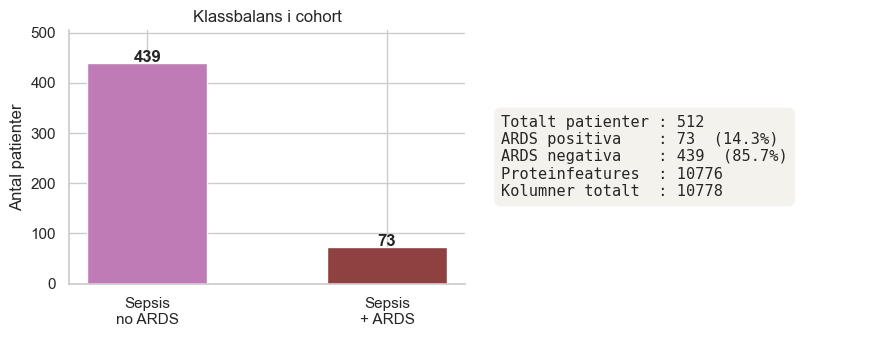

In [133]:
# 00

cohort = pd.read_parquet(DATA_PROC / "cohort.parquet")
protein_ids = json.loads((DATA_PROC / "protein_ids.json").read_text())

n_total  = len(cohort)
n_ards   = int(cohort["y"].sum())
n_noards = n_total - n_ards

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Vänster: klassbalans
ax = axes[0]
bars = ax.bar(["Sepsis\nno ARDS", "Sepsis\n+ ARDS"],
              [n_noards, n_ards],
              color=["#BE7BB5", "#8F4040"], width=0.5)
for bar, val in zip(bars, [n_noards, n_ards]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha="center", fontsize=12, fontweight="bold")
ax.set_title("Klassbalans i cohort")
ax.set_ylabel("Antal patienter")
ax.set_ylim(0, max(n_noards, n_ards) * 1.15)

# Höger: sammanfattning som text
ax2 = axes[1]
ax2.axis("off")
summary = (
    f"Totalt patienter : {n_total}\n"
    f"ARDS positiva    : {n_ards}  ({n_ards/n_total*100:.1f}%)\n"
    f"ARDS negativa    : {n_noards}  ({n_noards/n_total*100:.1f}%)\n"
    f"Proteinfeatures  : {len(protein_ids)}\n"
    f"Kolumner totalt  : {cohort.shape[1]}"
)
ax2.text(0.05, 0.5, summary, transform=ax2.transAxes,
        fontsize=11, va="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#F1EFE8", alpha=0.8))

plt.tight_layout()
plt.show()

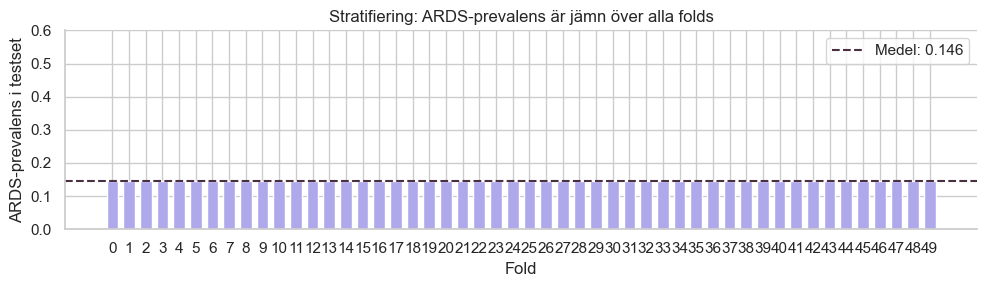

Min: 0.146  Max: 0.146  → tät spridning = stratifieringen fungerade


In [134]:
# 01

meta = json.loads((DATA_PROC / "splits_meta.json").read_text())

prev  = meta["test_prevalence_per_fold"]
n_folds = len(prev)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(n_folds), prev, color="#AFA9EC", width=0.7)
ax.axhline(np.mean(prev), color="#492F3F", linestyle="--", linewidth=1.5,
          label=f"Medel: {np.mean(prev):.3f}")
ax.set_xlabel("Fold")
ax.set_ylabel("ARDS-prevalens i testset")
ax.set_title("Stratifiering: ARDS-prevalens är jämn över alla folds")
ax.set_xticks(range(n_folds))
ax.set_ylim(0, 0.6)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Min: {min(prev):.3f}  Max: {max(prev):.3f}  → tät spridning = stratifieringen fungerade")


ttest — top 5 mest stabila proteiner (top-50):
   protein_id  frequency  mean_rank
 seq.26103.20       1.00       0.50
  seq.21184.1       1.00       6.02
seq.17792.158       0.96      12.68
  seq.7887.57       0.92      20.90
 seq.33451.35       0.90      23.04

random — top 5 mest stabila proteiner (top-50):
  protein_id  frequency  mean_rank
 seq.11168.3       0.08    4915.76
 seq.31745.6       0.08    5018.14
seq.17195.43       0.06    4966.26
seq.19200.16       0.06    5821.92
 seq.9925.56       0.06    5663.38

rf_shap — top 5 mest stabila proteiner (top-50):
   protein_id  frequency  mean_rank
  seq.4125.52       1.00       3.56
  seq.21240.6       1.00      11.10
  seq.6440.31       0.94      14.06
 seq.23224.11       0.94      14.56
seq.29150.106       0.88      19.10


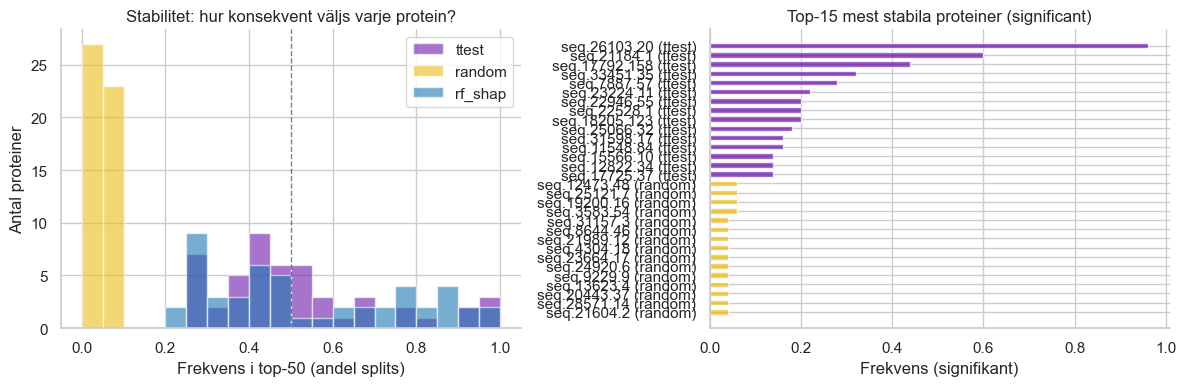

In [135]:
# 02

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vänster: histogram frekvens — top 50 proteiner per metod
for method in METHODS:
    topk = pd.read_parquet(RESULTS / "selection" / method / "stability_topk.parquet",
                           engine="fastparquet")
    k50  = (topk[topk["k"] == 50]
            .sort_values("frequency", ascending=False)
            .head(50))
    axes[0].hist(k50["frequency"], bins=20, alpha=0.6,
                color=COLORS[method], label=method, range=(0, 1))

axes[0].set_xlabel("Frekvens i top-50 (andel splits)")
axes[0].set_ylabel("Antal proteiner")
axes[0].set_title("Stabilitet: hur konsekvent väljs varje protein?")
axes[0].legend()
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)

# Top-5 print per metod
for method in METHODS:
    topk = pd.read_parquet(RESULTS / "selection" / method / "stability_topk.parquet",
                           engine="fastparquet")
    top5 = (topk[topk["k"] == 50]
            .sort_values("frequency", ascending=False)
            .head(5))
    print(f"\n{method} — top 5 mest stabila proteiner (top-50):")
    print(top5[["protein_id", "frequency", "mean_rank"]].to_string(index=False))

# Höger: stapeldiagram top-15 stabila proteiner — bara ttest och random (ej rf_shap)
METHODS_WITH_SIG = [m for m in METHODS if m != "rf_shap"]
for method in METHODS_WITH_SIG:
    stab = pd.read_parquet(RESULTS / "selection" / method / "stability_significant.parquet")
    top15 = stab.sort_values("frequency", ascending=False).head(15)
    axes[1].barh(
        [f"{p} ({method})" for p in top15["protein_id"]],
        top15["frequency"],
        color=COLORS[method], alpha=0.75, height=0.6
    )

axes[1].set_xlabel("Frekvens (signifikant)")
axes[1].set_title("Top-15 mest stabila proteiner (significant)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

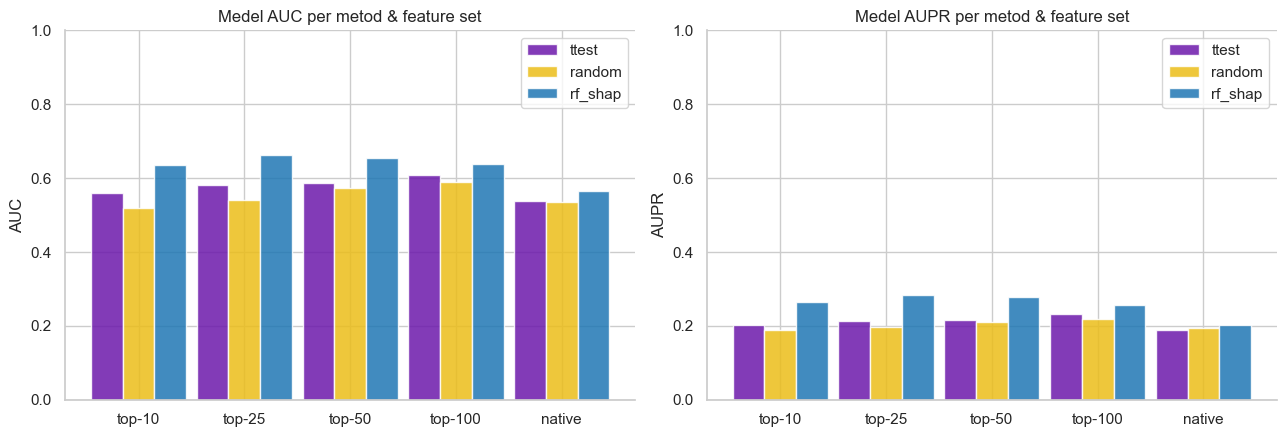


Medel AUC (alla klassificerare, alla k):
method
random     0.552
rf_shap    0.632
ttest      0.575


In [136]:
# 03

all_scores = []
for method in METHODS:
    engine = "fastparquet" if method == "rf_shap" else "pyarrow"
    df = pd.read_parquet(RESULTS / "classifier" / method / "scores.parquet",
                         engine=engine)
    df["method"] = method
    all_scores.append(df)
scores = pd.concat(all_scores, ignore_index=True)

classifiers = scores["classifier"].unique()
k_order     = [str(k) for k in sorted([x for x in scores["k"].unique() if x != "native"],
                key=int)] + ["native"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, metric in zip(axes, ["auc", "aupr"]):
    means = (scores.groupby(["method", "k", "classifier"])[metric]
             .mean().reset_index())

    n_methods = len(METHODS)
    n_k       = len(k_order)
    x         = np.arange(n_k)
    width     = 0.3

    for j, method in enumerate(METHODS):
        vals = []
        for k in k_order:
            row = means[(means["method"] == method) & (means["k"] == k)]
            vals.append(row[metric].mean() if len(row) > 0 else np.nan)
        offset = (j - n_methods/2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=method,
               color=COLORS[method], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([f"top-{k}" if k != "native" else "native" for k in k_order])
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Medel {metric.upper()} per metod & feature set")
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nMedel AUC (alla klassificerare, alla k):")
print(scores.groupby("method")["auc"].mean().round(3).to_string())

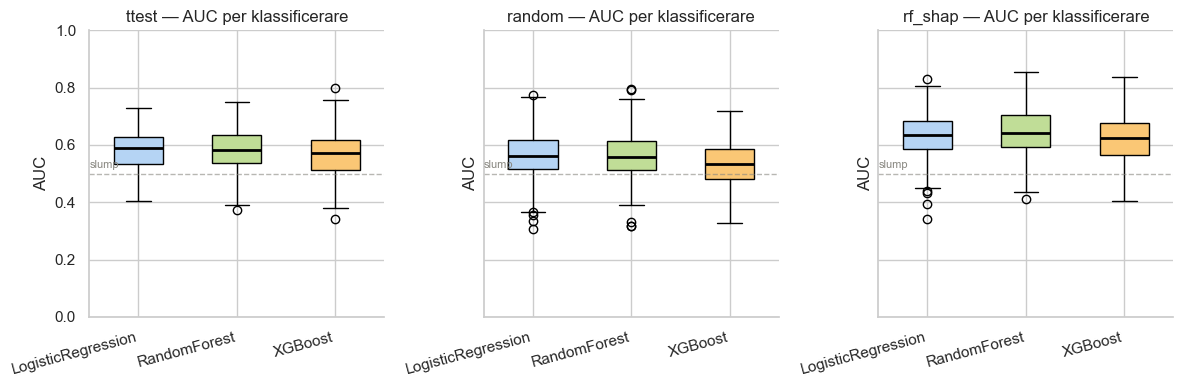

In [137]:
# 03

fig, axes = plt.subplots(1, len(METHODS), figsize=(12, 4), sharey=True)

for ax, method in zip(axes, METHODS):
    df = scores[scores["method"] == method]
    data_by_clf = [df[df["classifier"] == clf]["auc"].dropna().values
                   for clf in classifiers]
    bp = ax.boxplot(data_by_clf, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    clf_colors = ["#B5D4F4", "#C0DD97", "#FAC775"]
    for patch, col in zip(bp["boxes"], clf_colors):
        patch.set_facecolor(col)
    ax.set_xticks(range(1, len(classifiers)+1))
    ax.set_xticklabels(classifiers, rotation=15, ha="right")
    ax.set_title(f"{method} — AUC per klassificerare")
    ax.set_ylabel("AUC")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, linestyle="--", color="#888780", linewidth=1, alpha=0.6)
    ax.text(0.5, 0.52, "slump", fontsize=8, color="#888780")

plt.tight_layout()
plt.show()

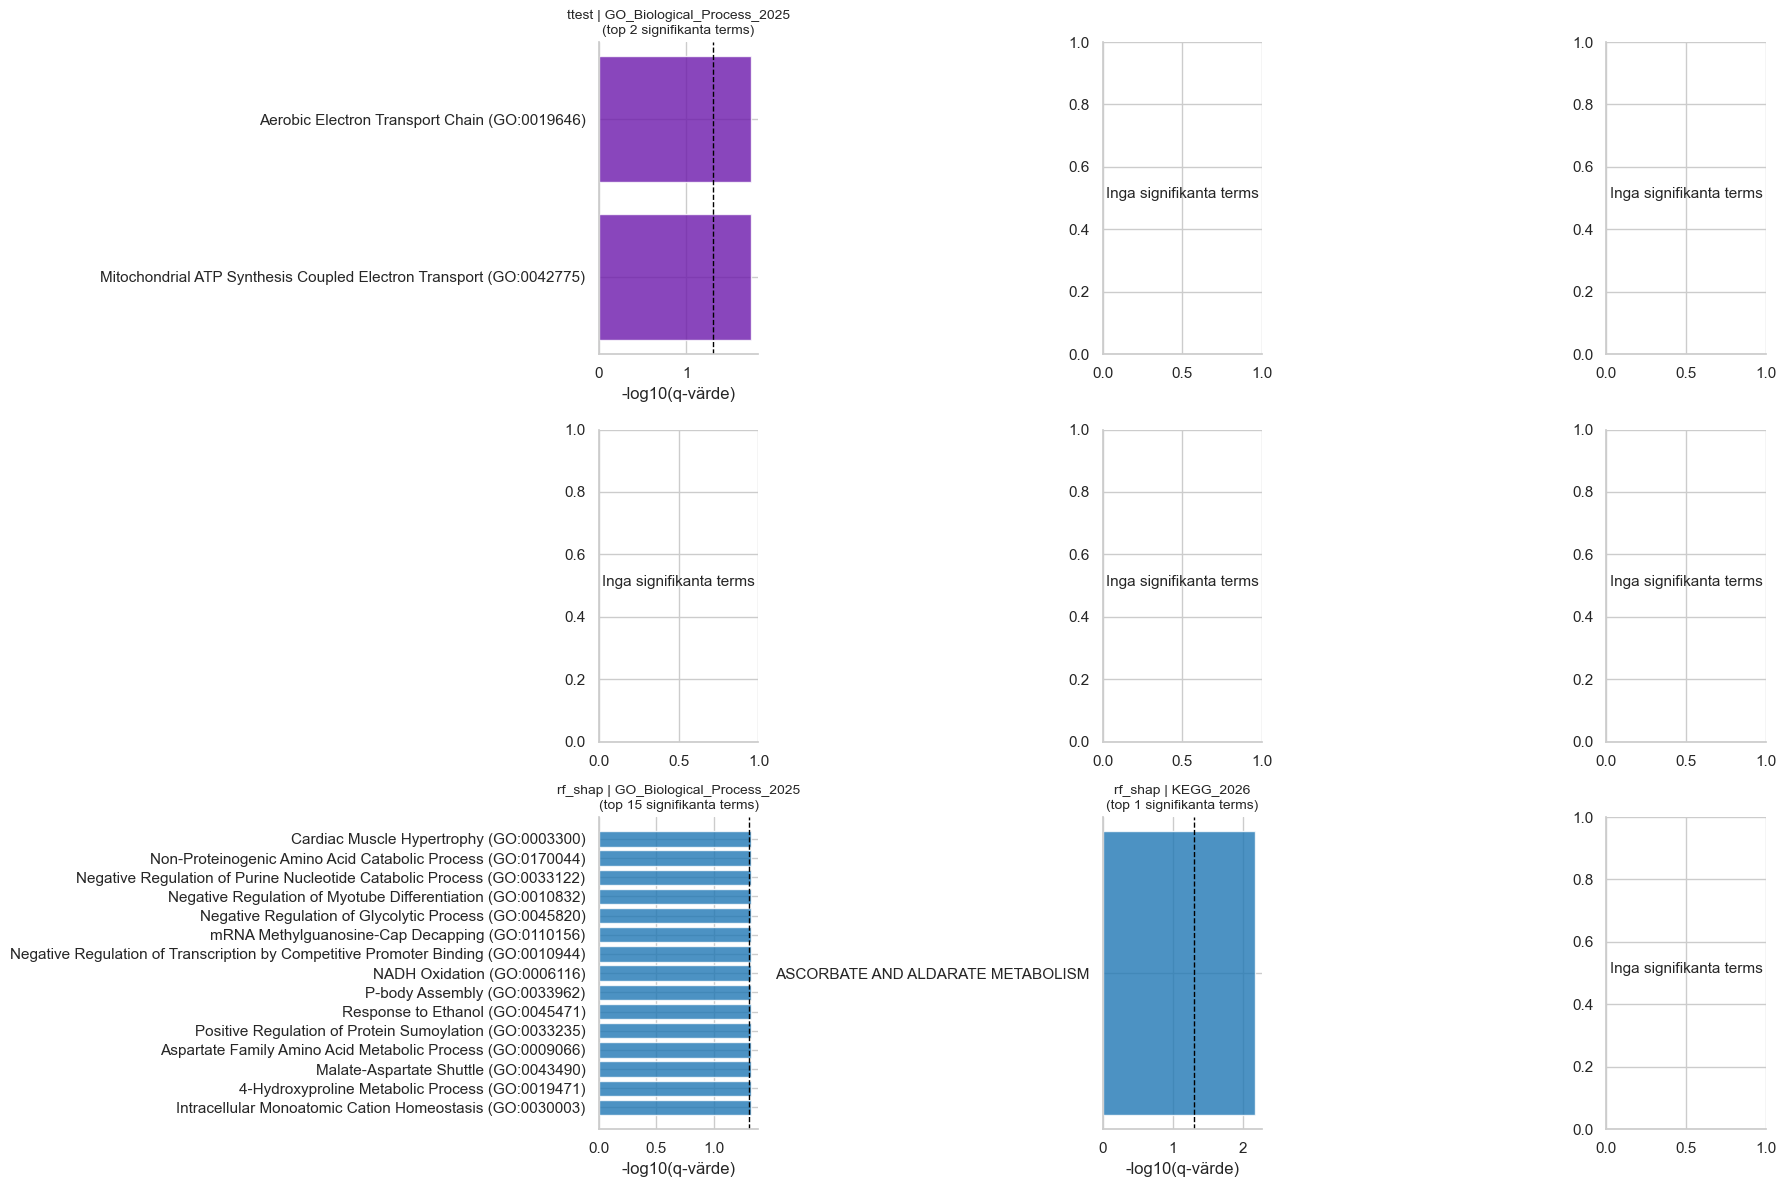

In [138]:
# 04

from src.config import ENRICHMENT_LIBRARIES, ENRICHMENT_Q_THRESHOLD

fig, axes = plt.subplots(len(METHODS), len(ENRICHMENT_LIBRARIES),
                         figsize=(6 * len(ENRICHMENT_LIBRARIES), 4 * len(METHODS)))
if len(METHODS) == 1: axes = [axes]

for i, method in enumerate(METHODS):
    for j, library in enumerate(ENRICHMENT_LIBRARIES):
        ax = axes[i][j]
        terms_path = RESULTS / "enrichment" / method / library / "terms.parquet"
        if not terms_path.exists():
            ax.text(0.5, 0.5, "fil saknas", ha="center", transform=ax.transAxes)
            continue

        engine = "fastparquet" if method == "rf_shap" else "pyarrow"
        terms = pd.read_parquet(terms_path, engine=engine)
        sig   = terms[terms["q_value"] < ENRICHMENT_Q_THRESHOLD].sort_values("q_value").head(15)

        if len(sig) == 0:
            ax.text(0.5, 0.5, "Inga signifikanta terms", ha="center", transform=ax.transAxes)
            continue

        ax.barh(sig["term"], -np.log10(sig["q_value"]),
                color=COLORS[method], alpha=0.8)
        ax.axvline(-np.log10(ENRICHMENT_Q_THRESHOLD), color="black",
                   linestyle="--", linewidth=1)
        ax.set_xlabel("-log10(q-värde)")
        ax.set_title(f"{method} | {library}\n(top {len(sig)} signifikanta terms)", fontsize=10)
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

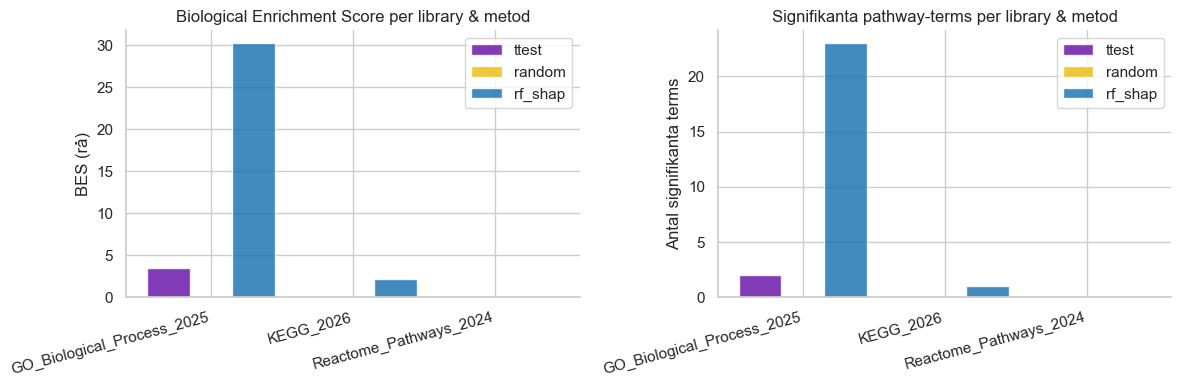


Full summary:
                   library  gene_list_size   bes_raw     bes_z  bes_p_emp  n_significant_terms  method
GO_Biological_Process_2025              12  3.468368 -0.172319   0.193613                    2   ttest
                 KEGG_2026              12  0.000000 -0.196642   1.000000                    0   ttest
    Reactome_Pathways_2024              12  0.000000 -0.110009   1.000000                    0   ttest
GO_Biological_Process_2025              20  0.000000 -0.243646   1.000000                    0  random
                 KEGG_2026              20  0.000000 -0.110437   1.000000                    0  random
    Reactome_Pathways_2024              20  0.000000 -0.109956   1.000000                    0  random
GO_Biological_Process_2025              10 30.232535  0.277803   0.284000                   23 rf_shap
                 KEGG_2026              10  2.166076  0.786808   0.080000                    1 rf_shap
    Reactome_Pathways_2024              10  0.000000 -0.25

In [139]:
# 04 

summary_rows = []
for method in METHODS:
    engine = "fastparquet" if method == "rf_shap" else "pyarrow"
    summ = pd.read_parquet(RESULTS / "enrichment" / method / "summary.parquet",
                           engine=engine)
    summ["method"] = method
    summary_rows.append(summ)
summary = pd.concat(summary_rows, ignore_index=True)

libraries = summary["library"].unique()
x      = np.arange(len(libraries))
width  = 0.3  # smalare för tre metoder

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# BES raw
for j, method in enumerate(METHODS):
    vals = [summary[(summary["method"]==method) & (summary["library"]==lib)]["bes_raw"].values
            for lib in libraries]
    vals = [v[0] if len(v) > 0 else np.nan for v in vals]
    offset = (j - len(METHODS)/2 + 0.5) * width
    axes[0].bar(x + offset, vals, width, label=method, color=COLORS[method], alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(libraries, rotation=15, ha="right")
axes[0].set_ylabel("BES (rå)")
axes[0].set_title("Biological Enrichment Score per library & metod")
axes[0].legend()

# Antal signifikanta terms
for j, method in enumerate(METHODS):
    vals = [summary[(summary["method"]==method) & (summary["library"]==lib)]["n_significant_terms"].values
            for lib in libraries]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    offset = (j - len(METHODS)/2 + 0.5) * width
    axes[1].bar(x + offset, vals, width, label=method, color=COLORS[method], alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(libraries, rotation=15, ha="right")
axes[1].set_ylabel("Antal signifikanta terms")
axes[1].set_title("Signifikanta pathway-terms per library & metod")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nFull summary:")
print(summary.to_string(index=False))

In [140]:
# 05 rf_shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT    = Path("/Users/lisafredriksson/Desktop/Skrivbord/Python/Exjobb/MSc26_Proteomics")
results = pd.read_parquet(ROOT / "results/simulation/rf_shap/results.parquet")

SIGNAL_TYPES = ["linear", "saturation", "threshold", "u_shape", "xor_pair"]
EFFECT_SIZES = sorted(results["effect_size"].unique())
K_ORDER      = ["10", "25", "50", "100"]  # native hoppas över (all False)

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "font.size": 11,
})
print(f"Laddade {len(results)} rader, {results['repeat'].nunique()} repeats.")

Laddade 3750 rader, 50 repeats.


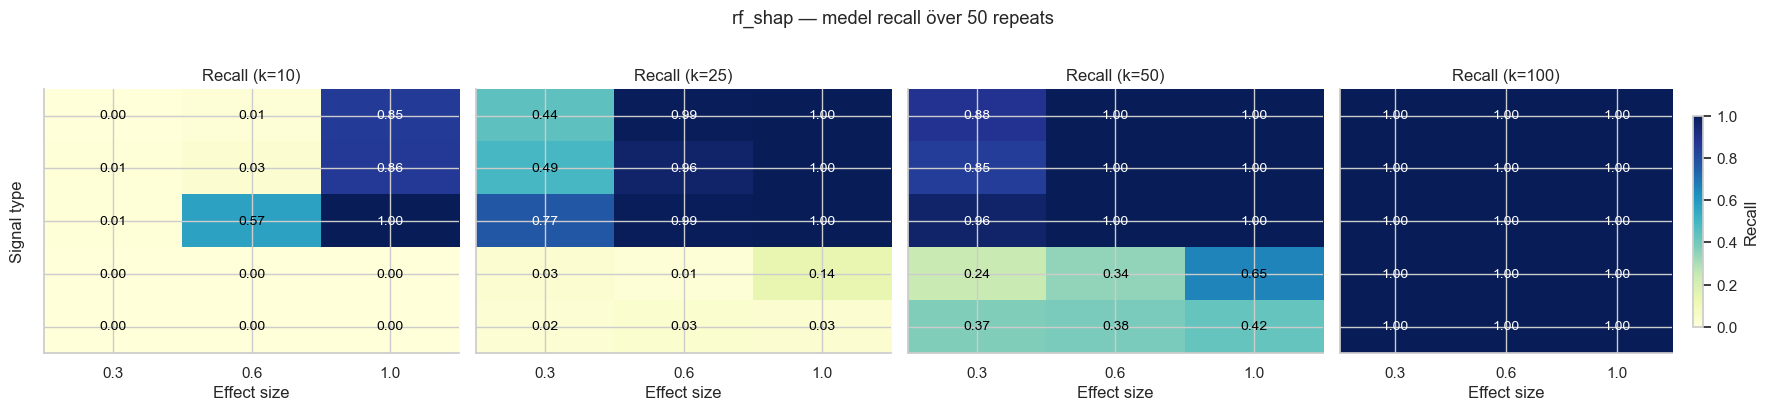

In [141]:
df = results[results["k"].isin(K_ORDER)]

fig, axes = plt.subplots(1, len(K_ORDER), figsize=(4.5 * len(K_ORDER), 4),
                         sharey=True)

for ax, k in zip(axes, K_ORDER):
    pivot = (df[df["k"] == k]
             .groupby(["signal_type", "effect_size"])["recall"]
             .mean()
             .unstack("effect_size")
             .reindex(SIGNAL_TYPES))

    im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(len(EFFECT_SIZES)))
    ax.set_xticklabels([str(e) for e in EFFECT_SIZES])
    ax.set_yticks(range(len(SIGNAL_TYPES)))
    ax.set_yticklabels(SIGNAL_TYPES if ax == axes[0] else [])
    ax.set_xlabel("Effect size")
    ax.set_title(f"Recall (k={k})")

    for r in range(len(SIGNAL_TYPES)):
        for c in range(len(EFFECT_SIZES)):
            val = pivot.values[r, c]
            if np.isfinite(val):
                ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                        fontsize=10,
                        color="white" if val > 0.7 else "black")

axes[0].set_ylabel("Signal type")
fig.colorbar(im, ax=axes[-1], label="Recall", shrink=0.8)
fig.suptitle("rf_shap — medel recall över 50 repeats", y=1.02)
plt.tight_layout()
plt.show()

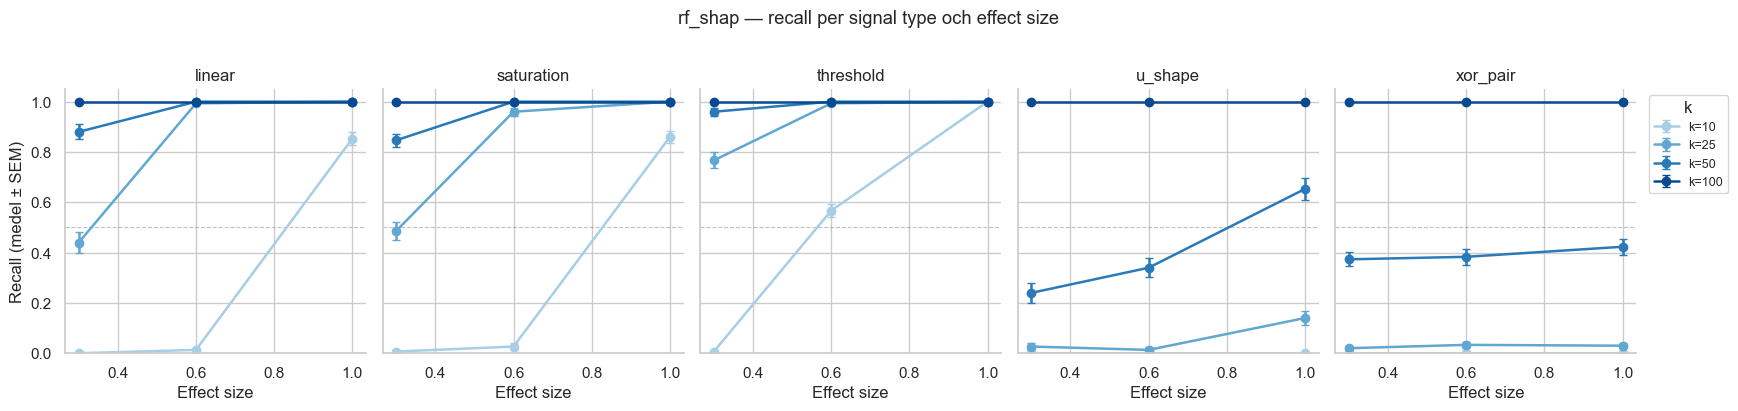

In [142]:
colors_k = plt.cm.Blues(np.linspace(0.35, 0.9, len(K_ORDER)))

fig, axes = plt.subplots(1, len(SIGNAL_TYPES),
                         figsize=(3.5 * len(SIGNAL_TYPES), 4),
                         sharey=True)

for ax, sig_type in zip(axes, SIGNAL_TYPES):
    sub = results[(results["signal_type"] == sig_type) &
                  (results["k"].isin(K_ORDER))]
    for i, k in enumerate(K_ORDER):
        grp   = sub[sub["k"] == k].groupby("effect_size")["recall"]
        means = grp.mean()
        sems  = grp.sem()
        ax.errorbar(means.index, means.values, yerr=sems.values,
                    marker="o", label=f"k={k}",
                    color=colors_k[i], linewidth=1.8, capsize=3)
    ax.set_title(sig_type)
    ax.set_xlabel("Effect size")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, linestyle="--", color="#888780",
               linewidth=0.8, alpha=0.5)

axes[0].set_ylabel("Recall (medel ± SEM)")
axes[-1].legend(title="k", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.suptitle("rf_shap — recall per signal type och effect size", y=1.02)
plt.tight_layout()
plt.show()

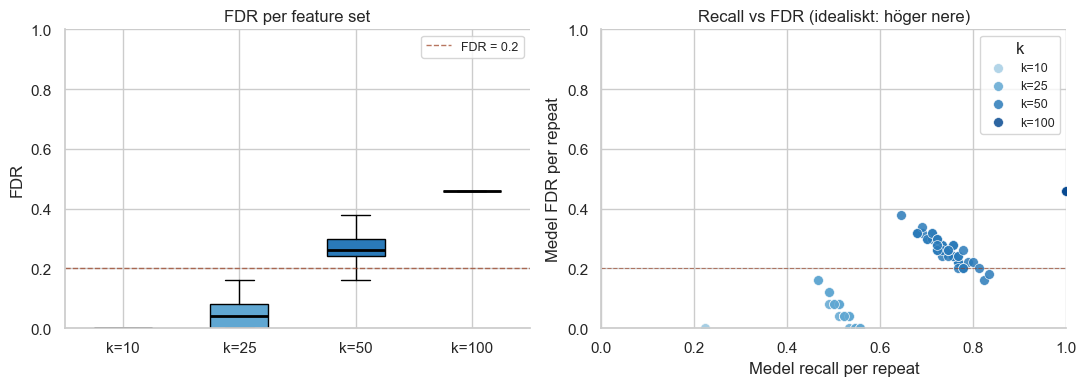

In [143]:
fdr_data = results[results["k"].isin(K_ORDER)].dropna(subset=["fdr"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Vänster: boxplot FDR per k
ax = axes[0]
data_by_k = [fdr_data[fdr_data["k"] == k]["fdr"].values for k in K_ORDER]
bp = ax.boxplot(data_by_k, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2))
for patch, col in zip(bp["boxes"], colors_k):
    patch.set_facecolor(col)
ax.set_xticks(range(1, len(K_ORDER) + 1))
ax.set_xticklabels([f"k={k}" for k in K_ORDER])
ax.set_ylabel("FDR")
ax.set_ylim(0, 1)
ax.set_title("FDR per feature set")
ax.axhline(0.2, linestyle="--", color="#993C1D",
           linewidth=1, alpha=0.7, label="FDR = 0.2")
ax.legend(fontsize=9)

# Höger: recall vs FDR scatter (medel per repeat, k=50)
ax2 = axes[1]
for i, k in enumerate(K_ORDER):
    sub  = results[results["k"] == k].dropna(subset=["fdr"])
    r_mean = sub.groupby("repeat")["recall"].mean()
    f_mean = sub.groupby("repeat")["fdr"].mean()
    ax2.scatter(r_mean, f_mean, label=f"k={k}", color=colors_k[i],
                edgecolors="white", s=50, linewidth=0.5, alpha=0.85)

ax2.axhline(0.2, linestyle="--", color="#993C1D", linewidth=0.8, alpha=0.6)
ax2.set_xlabel("Medel recall per repeat")
ax2.set_ylabel("Medel FDR per repeat")
ax2.set_title("Recall vs FDR (idealiskt: höger nere)")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.legend(title="k", fontsize=9)

plt.tight_layout()
plt.show()

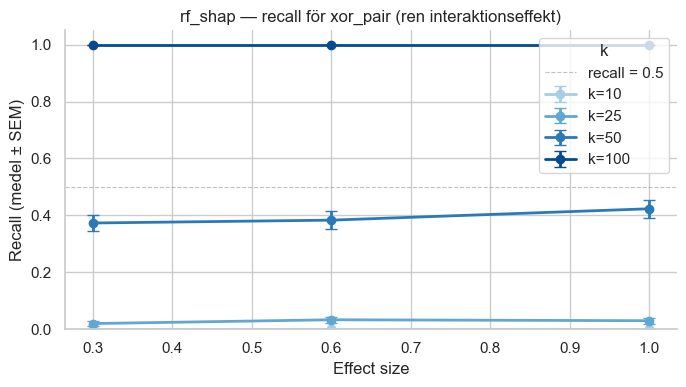


xor_pair — medel recall:
effect_size    0.3    0.6    1.0
k                               
10           0.000  0.000  0.000
100          1.000  1.000  1.000
25           0.020  0.033  0.030
50           0.373  0.383  0.423


In [144]:
xor = results[(results["signal_type"] == "xor_pair") &
              (results["k"].isin(K_ORDER))]

fig, ax = plt.subplots(figsize=(7, 4))

for i, k in enumerate(K_ORDER):
    grp   = xor[xor["k"] == k].groupby("effect_size")["recall"]
    means = grp.mean()
    sems  = grp.sem()
    ax.errorbar(means.index, means.values, yerr=sems.values,
                marker="o", label=f"k={k}",
                color=colors_k[i], linewidth=2, capsize=4)

ax.set_xlabel("Effect size")
ax.set_ylabel("Recall (medel ± SEM)")
ax.set_title("rf_shap — recall för xor_pair (ren interaktionseffekt)")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, linestyle="--", color="#888780",
           linewidth=0.8, alpha=0.5, label="recall = 0.5")
ax.legend(title="k")

plt.tight_layout()
plt.show()

print("\nxor_pair — medel recall:")
print(xor.groupby(["k", "effect_size"])["recall"]
        .mean().round(3).unstack("effect_size").to_string())

# Explore RF adaptive proteins

In [145]:
# Exploring adaptive number of proteins rf_shap

COHORT_PATH = "data/processed/cohort.parquet"
RESULTS_DIR = "results/selection/rf_shap"
ARDS_COL    = "y"

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
import shap

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42

In [147]:
cohort = pd.read_parquet(COHORT_PATH)
print("Shape:", cohort.shape)

protein_cols = [c for c in cohort.columns if c not in ["patient_id", ARDS_COL]]
print(f"Protein columns: {len(protein_cols)}")

cohort = cohort.dropna(subset=[ARDS_COL])

X = cohort[protein_cols].values.astype(float)
y = cohort[ARDS_COL].astype(int).values

print(f"X shape: {X.shape}")
print(f"y — ARDS=1: {y.sum()}, ARDS=0: {(y==0).sum()}")

Shape: (512, 10778)
Protein columns: 10776
X shape: (512, 10776)
y — ARDS=1: 73, ARDS=0: 439


In [148]:
import time
start = time.time()
rf = RandomForestClassifier(
    n_estimators=10000,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, y)
elapsed = time.time() - start
print(f"En körning (10 000 träd): {elapsed:.1f} sekunder")
print(f"Uppskattad total (21 splits): {21*elapsed/60:.1f} minuter")
print(f"Uppskattad total med SHAP:    {21*elapsed*3/60:.1f} minuter (SHAP tar ~2-3x längre än fit)")

En körning (10 000 träd): 32.9 sekunder
Uppskattad total (21 splits): 11.5 minuter
Uppskattad total med SHAP:    34.6 minuter (SHAP tar ~2-3x längre än fit)


In [ ]:
explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X, check_additivity=False)

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_class1 = np.abs(shap_values[:, :, 1])
elif isinstance(shap_values, list):
    shap_class1 = np.abs(shap_values[1])
else:
    shap_class1 = np.abs(shap_values)

mean_abs_shap = shap_class1.mean(axis=0)
std_abs_shap  = shap_class1.std(axis=0)
snr           = mean_abs_shap / (std_abs_shap + 1e-9)

print(f"shap_class1 shape : {shap_class1.shape}")
print(f"mean_abs_shap     : min={mean_abs_shap.min():.2e}, max={mean_abs_shap.max():.2e}")
print(f"std_abs_shap      : min={std_abs_shap.min():.2e},  max={std_abs_shap.max():.2e}")
print(f"SNR               : min={snr.min():.3f}, max={snr.max():.3f}, median={np.median(snr):.3f}")

In [ ]:
# ── Definiera allt som behövs ─────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

# shap_raw — signerat SHAP för klass 1
shap_raw = shap_values[:, :, 1] if (isinstance(shap_values, np.ndarray) and shap_values.ndim == 3) else shap_values[1]

print(f"shap_raw shape: {shap_raw.shape}")
print("Allt definierat — kör nästa cell!")

shap_raw shape: (512, 10776)
Allt definierat — kör nästa cell!


: 

ARDS-patienter: 73
Förklarad varians 50 komponenter: 84.6%
k=2: silhouette=0.0568
k=3: silhouette=0.0565
k=4: silhouette=0.0391
k=5: silhouette=0.0373
k=6: silhouette=0.0405
k=7: silhouette=0.0299


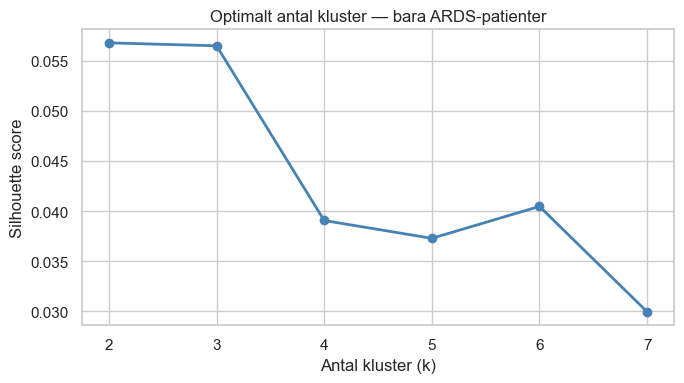

: 

In [ ]:
# ── Direkt på alla ARDS-patienter ────────────────────────────────────────────
mask_ards_all = y == 1
shap_ards_all = shap_raw[mask_ards_all]   # (73, 10776)

print(f"ARDS-patienter: {mask_ards_all.sum()}")

# PCA för stabilitet
pca_ards = PCA(n_components=50, random_state=SEED)
shap_ards_pca = pca_ards.fit_transform(shap_ards_all)
print(f"Förklarad varians 50 komponenter: {pca_ards.explained_variance_ratio_.sum():.1%}")

# Silhouette för optimalt k
scores_ards = []
ks = range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(shap_ards_pca)
    s = silhouette_score(shap_ards_pca, labels)
    scores_ards.append(s)
    print(f"k={k}: silhouette={s:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, scores_ards, marker="o", color="steelblue", lw=2)
ax.set_xlabel("Antal kluster (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Optimalt antal kluster — bara ARDS-patienter")
plt.tight_layout()
plt.show()


ARDS-subtyper (k=2):
  Subtyp 0: n=30
  Subtyp 1: n=43


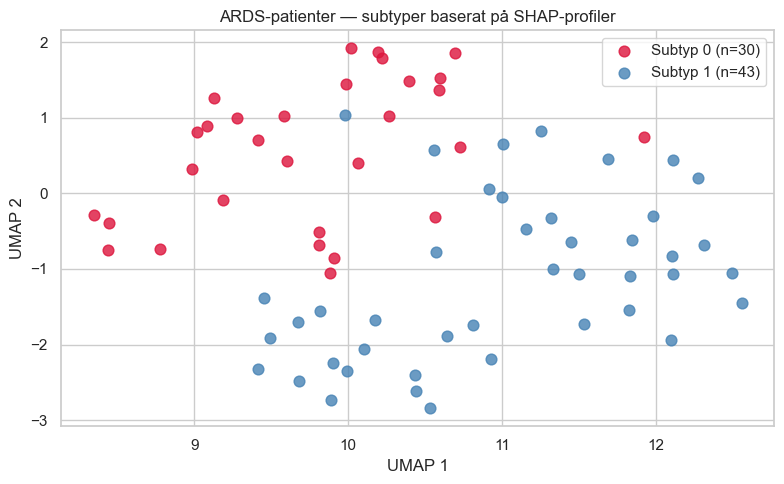

: 

In [ ]:
# ── Klustra med bästa k — justera K_ARDS efter silhouette ────────────────────
K_ARDS = 2  # ändra efter silhouette-kurvan

km_ards = KMeans(n_clusters=K_ARDS, random_state=SEED, n_init=20)
ards_subtypes = km_ards.fit_predict(shap_ards_pca)

print(f"\nARDS-subtyper (k={K_ARDS}):")
for k in range(K_ARDS):
    mask_k = ards_subtypes == k
    print(f"  Subtyp {k}: n={mask_k.sum()}")

# ── UMAP ─────────────────────────────────────────────────────────────────────
reducer_ards = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
embedding_ards = reducer_ards.fit_transform(shap_ards_all)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["crimson", "steelblue", "seagreen", "darkorange"]
for k in range(K_ARDS):
    mask_k = ards_subtypes == k
    ax.scatter(embedding_ards[mask_k, 0], embedding_ards[mask_k, 1],
               s=60, alpha=0.8, color=colors[k], label=f"Subtyp {k} (n={mask_k.sum()})")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("ARDS-patienter — subtyper baserat på SHAP-profiler")
ax.legend()
plt.tight_layout()
plt.show()

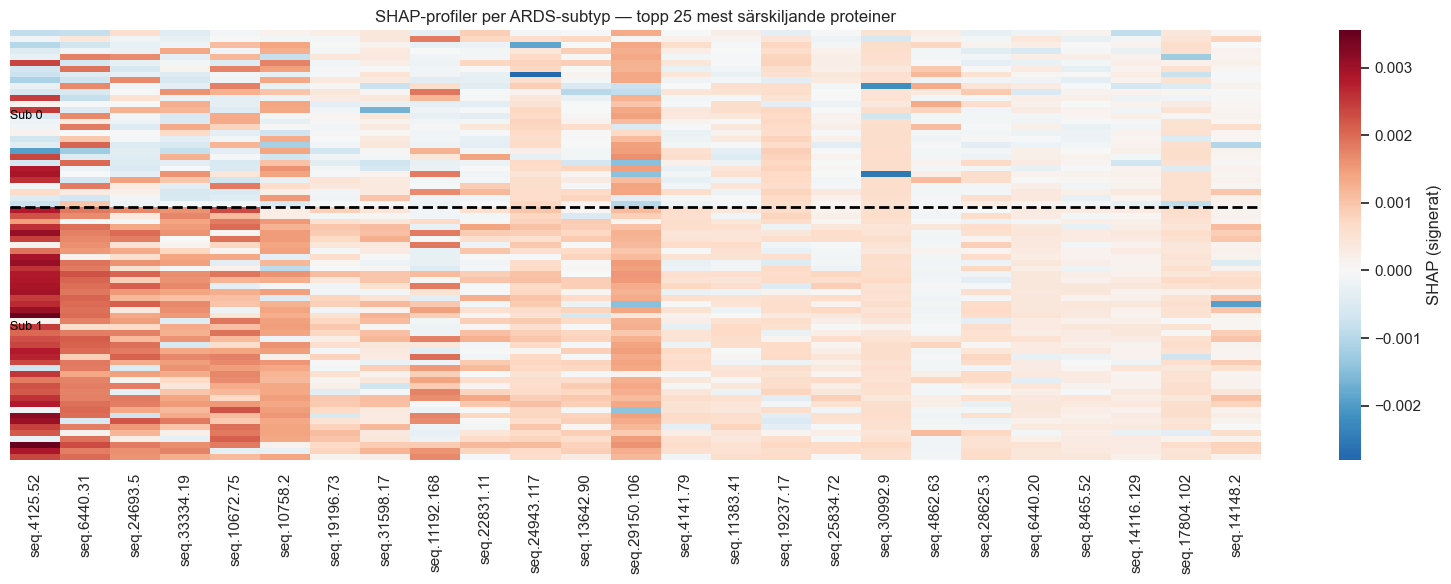

: 

In [ ]:
# ── Vilka proteiner skiljer subtyperna åt? ────────────────────────────────────
# Variation inom ARDS — vilka proteiner beter sig olika mellan subtyper?
var_between = np.array([
    np.var([shap_ards_all[ards_subtypes == k, i].mean() for k in range(K_ARDS)])
    for i in range(shap_ards_all.shape[1])
])
top_var_idx_ards = np.argsort(-var_between)[:25]

# Heatmap
shap_plot = np.vstack([
    shap_ards_all[ards_subtypes == k][:, top_var_idx_ards]
    for k in range(K_ARDS)
])
boundaries = np.cumsum([(ards_subtypes == k).sum() for k in range(K_ARDS)])[:-1]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(shap_plot, ax=ax, cmap="RdBu_r", center=0,
            xticklabels=[protein_cols[i] for i in top_var_idx_ards],
            yticklabels=False,
            cbar_kws={"label": "SHAP (signerat)"})
for b in boundaries:
    ax.axhline(b, color="black", lw=2, linestyle="--")
for k in range(K_ARDS):
    y_pos = sum((ards_subtypes == j).sum() for j in range(k)) + (ards_subtypes == k).sum() // 2
    ax.text(0, y_pos, f"Sub {k}", fontsize=9, color="black")
ax.set_title("SHAP-profiler per ARDS-subtyp — topp 25 mest särskiljande proteiner")
plt.tight_layout()
plt.show()

In [ ]:
# Ladda annotation
annot = pd.read_csv("data/processed/somalogic_annotation.csv")

: 

Mest särskiljande protein: seq.4125.52
Symbol  : AGER
Gennamn : advanced glycosylation end-product specific receptor


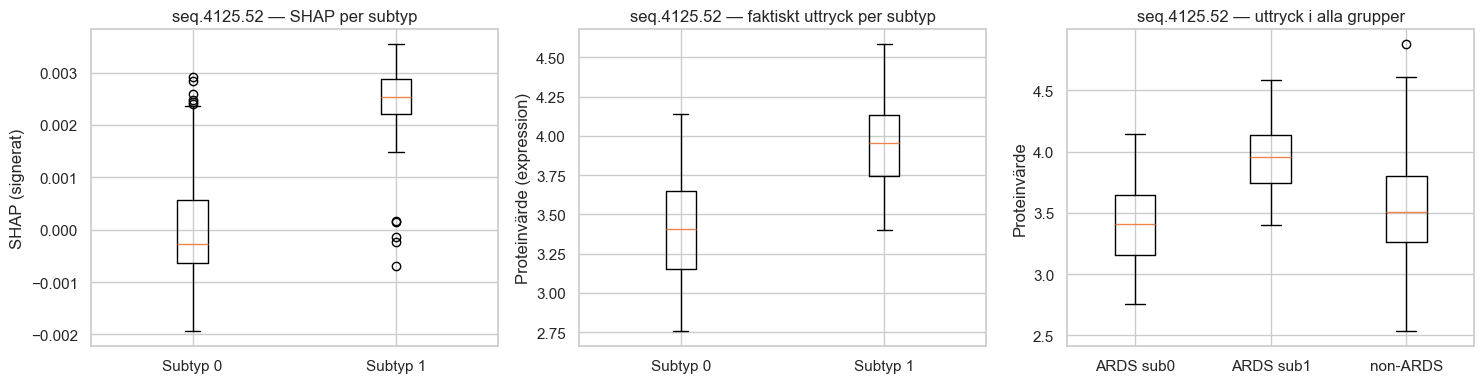


=== Statistiska tester ===
Subtyp 0 vs non-ARDS (lägre): p=0.1480, mean subtyp=3.424, mean non-ARDS=3.533
Subtyp 1 vs non-ARDS (högre): p=0.0000, mean subtyp=3.983, mean non-ARDS=3.533
Subtyp 0 vs subtyp 1: p=0.0000


: 

In [ ]:
# ── Topp mest särskiljande protein mellan subtyperna ─────────────────────────
# Hitta proteinet med högst variation mellan subtyperna
top_prot_idx = top_var_idx_ards[0]
top_prot_name = protein_cols[top_prot_idx]

print(f"Mest särskiljande protein: {top_prot_name}")

# Slå upp annotation
probe_id = top_prot_name.replace("seq.", "").replace(".", "-")
hit = annot[annot["PROBEID"] == probe_id]
if len(hit) > 0:
    print(f"Symbol  : {hit['SYMBOL'].values[0]}")
    print(f"Gennamn : {hit['GENENAME'].values[0]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. SHAP-värden per subtyp
ax = axes[0]
ax.boxplot([
    shap_ards_all[ards_subtypes == k, top_prot_idx]
    for k in range(K_ARDS)
], labels=[f"Subtyp {k}" for k in range(K_ARDS)])
ax.set_ylabel("SHAP (signerat)")
ax.set_title(f"{top_prot_name} — SHAP per subtyp")

# 2. Faktiskt proteinvärde per subtyp
ards_idx = np.where(mask_ards_all)[0]
expr_per_subtype = [X[ards_idx[ards_subtypes == k], top_prot_idx] for k in range(K_ARDS)]
expr_noards = X[y == 0, top_prot_idx]

ax = axes[1]
ax.boxplot(expr_per_subtype, labels=[f"Subtyp {k}" for k in range(K_ARDS)])
ax.set_ylabel("Proteinvärde (expression)")
ax.set_title(f"{top_prot_name} — faktiskt uttryck per subtyp")

# 3. Jämför med non-ARDS
ax = axes[2]
ax.boxplot(
    expr_per_subtype + [expr_noards],
    labels=[f"ARDS sub{k}" for k in range(K_ARDS)] + ["non-ARDS"]
)
ax.set_ylabel("Proteinvärde")
ax.set_title(f"{top_prot_name} — uttryck i alla grupper")

plt.tight_layout()
plt.show()

# ── Statistiska tester ────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu

print("\n=== Statistiska tester ===")
for k in range(K_ARDS):
    expr_k = expr_per_subtype[k]
    stat, p = mannwhitneyu(expr_k, expr_noards, alternative="two-sided")
    direction = "högre" if expr_k.mean() > expr_noards.mean() else "lägre"
    print(f"Subtyp {k} vs non-ARDS ({direction}): p={p:.4f}, "
          f"mean subtyp={expr_k.mean():.3f}, mean non-ARDS={expr_noards.mean():.3f}")

for i in range(K_ARDS):
    for j in range(i+1, K_ARDS):
        stat, p = mannwhitneyu(expr_per_subtype[i], expr_per_subtype[j], alternative="two-sided")
        print(f"Subtyp {i} vs subtyp {j}: p={p:.4f}")

In [ ]:
# Kolla SHAP-värden för ARDS-patienter över ALLA proteiner, inte bara topp 25
shap_alla_ards = shap_raw[y == 1]  # alla 73 ARDS-patienter, alla proteiner

print(f"ARDS-patienter: {shap_alla_ards.shape[0]}")
print(f"Andel negativa SHAP-värden bland ARDS-patienter: {(shap_alla_ards < 0).mean():.1%}")
print(f"Andel positiva SHAP-värden bland ARDS-patienter: {(shap_alla_ards > 0).mean():.1%}")

# Per patient — har varje ARDS-patient övervägande positiv eller negativ SHAP?
per_patient_mean = shap_alla_ards.mean(axis=1)
print(f"\nARDS-patienter med positivt mean SHAP: {(per_patient_mean > 0).sum()}")
print(f"ARDS-patienter med negativt mean SHAP: {(per_patient_mean < 0).sum()}")

ARDS-patienter: 73
Andel negativa SHAP-värden bland ARDS-patienter: 37.8%
Andel positiva SHAP-värden bland ARDS-patienter: 62.2%

ARDS-patienter med positivt mean SHAP: 73
ARDS-patienter med negativt mean SHAP: 0


: 

=== Överlapp med kombinerat mått ===
combined  ∩  mean pos SHAP : 22/25
combined  ∩  diff          : 23/25
Alla tre                   : 22/25

Bara i combined (n=2):
  CROT: combined=0.323269, pos=0.000493, diff=0.000930
  ALDH2: combined=0.315350, pos=0.000431, diff=0.000882


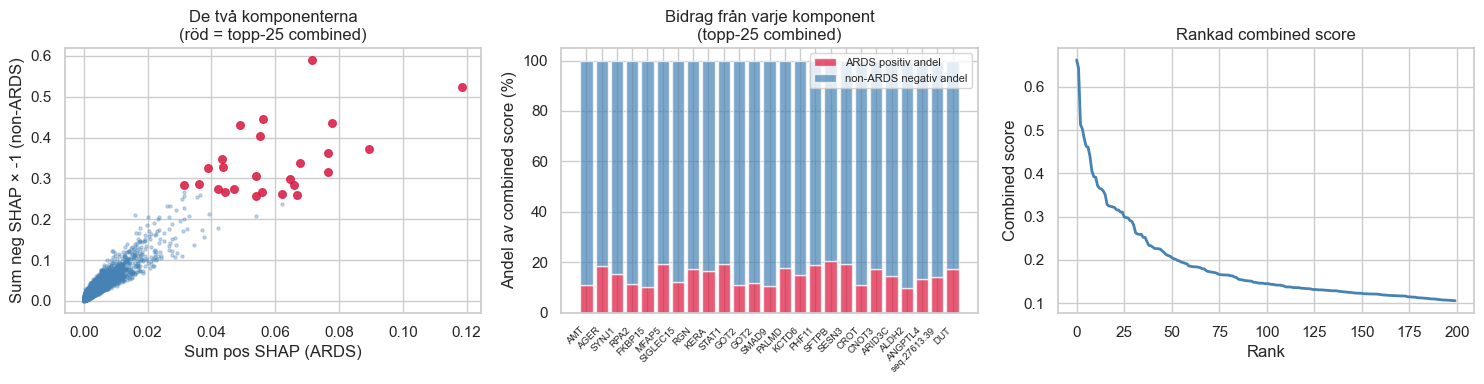

: 

In [ ]:
shap_ards   = shap_raw[y == 1]
shap_noards = shap_raw[y == 0]

# ── Ditt föreslagna mått ──────────────────────────────────────────────────────
# Summa av positiva ARDS-bidrag (tar bara de som faktiskt driver mot ARDS)
sum_pos_ards   = np.where(shap_ards > 0, shap_ards, 0).sum(axis=0)

# Summa av negativa non-ARDS-bidrag (tar bara de som driver bort från ARDS)
# Multiplicera med -1 så att det blir positivt
sum_neg_noards = np.where(shap_noards < 0, shap_noards, 0).sum(axis=0) * -1

# Kombinerat mått
combined = sum_pos_ards + sum_neg_noards

# ── Jämför med befintliga mått ────────────────────────────────────────────────
mean_pos_ards  = np.where(shap_ards > 0, shap_ards, 0).mean(axis=0)
diff_correct   = shap_ards.mean(axis=0) - shap_noards.mean(axis=0)

top_combined = set(np.argsort(-combined)[:25])
top_pos      = set(np.argsort(-mean_pos_ards)[:25])
top_diff     = set(np.argsort(-diff_correct)[:25])

print("=== Överlapp med kombinerat mått ===")
print(f"combined  ∩  mean pos SHAP : {len(top_combined & top_pos)}/25")
print(f"combined  ∩  diff          : {len(top_combined & top_diff)}/25")
print(f"Alla tre                   : {len(top_combined & top_pos & top_diff)}/25")

# Vad hittar combined som de andra missar?
only_combined = top_combined - top_pos - top_diff
print(f"\nBara i combined (n={len(only_combined)}):")
for i in sorted(only_combined, key=lambda i: -combined[i]):
    symbol = get_symbol(protein_cols[i])
    print(f"  {symbol}: combined={combined[i]:.6f}, "
          f"pos={mean_pos_ards[i]:.6f}, "
          f"diff={diff_correct[i]:.6f}")

# Visualisera de två komponenterna
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(sum_pos_ards, sum_neg_noards, s=5, alpha=0.3, color="steelblue")
# Markera topp-25 combined
for i in top_combined:
    ax.scatter(sum_pos_ards[i], sum_neg_noards[i],
               s=30, color="crimson", alpha=0.8, zorder=3)
ax.set_xlabel("Sum pos SHAP (ARDS)")
ax.set_ylabel("Sum neg SHAP × -1 (non-ARDS)")
ax.set_title("De två komponenterna\n(röd = topp-25 combined)")

ax = axes[1]
# Hur stor är varje komponent för topp-25?
top25_combined = sorted(top_combined, key=lambda i: -combined[i])
pos_contrib  = [sum_pos_ards[i] / combined[i] * 100 for i in top25_combined]
neg_contrib  = [sum_neg_noards[i] / combined[i] * 100 for i in top25_combined]
symbols      = [get_symbol(protein_cols[i]) for i in top25_combined]

x = range(len(top25_combined))
ax.bar(x, pos_contrib, color="crimson", alpha=0.7, label="ARDS positiv andel")
ax.bar(x, neg_contrib, bottom=pos_contrib, color="steelblue",
       alpha=0.7, label="non-ARDS negativ andel")
ax.set_xticks(x)
ax.set_xticklabels(symbols, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Andel av combined score (%)")
ax.set_title("Bidrag från varje komponent\n(topp-25 combined)")
ax.legend(fontsize=8)

ax = axes[2]
# Rankad combined score
combined_sorted = np.sort(combined)[::-1]
ax.plot(combined_sorted[:200], color="steelblue", lw=2)
ax.set_xlabel("Rank")
ax.set_ylabel("Combined score")
ax.set_title("Rankad combined score")

plt.tight_layout()
plt.show()

In [ ]:
# ── Primärt rankingmått: mean |SHAP| på ARDS-patienter ───────────────────────
shap_abs_ards     = np.abs(shap_raw[y == 1])
ards_mean_abs     = shap_abs_ards.mean(axis=0)          # primärt mått
mean_abs_all      = np.abs(shap_raw).mean(axis=0)       # pipeline idag
diff          
k = 1000
# Topp-sett för varje mått
top_ards_abs_set  = set(np.argsort(-ards_mean_abs)[:k])
top_diff_set      = set(np.argsort(-diff)[:k])
top_all_abs_set   = set(np.argsort(-mean_abs_all)[:k])

print("=== Överlapp med primärt mått (mean |SHAP| ARDS) ===")
print(f"ARDS |SHAP|  ∩  differens    : {len(top_ards_abs_set & top_diff_set)/k}")
print(f"ARDS |SHAP|  ∩  alla |SHAP|  : {len(top_ards_abs_set & top_all_abs_set)/k}")
print(f"differens    ∩  alla |SHAP|  : {len(top_diff_set & top_all_abs_set)/k}")
print(f"Alla tre                     : {len(top_ards_abs_set & top_diff_set & top_all_abs_set)/k}")

# ── Bygg rankad lista med robusthetsflagga ────────────────────────────────────
ranked_idx = np.argsort(-ards_mean_abs)

rows = []
for rank, prot_i in enumerate(ranked_idx[:k]):
    seq_id   = protein_cols[prot_i]
    probe_id = seq_id.replace("seq.", "").replace(".", "-")
    hit      = annot[annot["PROBEID"] == probe_id]
    symbol   = hit["SYMBOL"].values[0] if len(hit) > 0 else "?"

    in_diff     = prot_i in top_diff_set
    in_all_abs  = prot_i in top_all_abs_set
    robust      = in_diff and in_all_abs   # finns i alla tre

    rows.append({
        "rank"          : rank + 1,
        "protein"       : seq_id,
        "symbol"        : symbol,
        "ards_mean_abs" : ards_mean_abs[prot_i],
        "in_diff"       : in_diff,
        "in_all_abs"    : in_all_abs,
        "robust"        : robust,
    })

df_ranked = pd.DataFrame(rows)
print("\nTopp-k proteiner — rankade på mean |SHAP| ARDS:")
print(df_ranked[["rank", "symbol", "ards_mean_abs",
                  "in_diff", "in_all_abs", "robust"]].to_string())

# Markera robusta
n_robust = df_ranked["robust"].sum()
print(f"\nRobusta proteiner (i alla tre mått) inom topp-k: {n_robust}")

=== Överlapp med primärt mått (mean |SHAP| ARDS) ===
ARDS |SHAP|  ∩  differens    : 0.375
ARDS |SHAP|  ∩  alla |SHAP|  : 0.871
differens    ∩  alla |SHAP|  : 0.269
Alla tre                     : 0.269

Topp-k proteiner — rankade på mean |SHAP| ARDS:
     rank     symbol  ards_mean_abs  in_diff  in_all_abs  robust
0       1       AGER       0.001805     True        True    True
1       2      MFAP5       0.001349     True        True    True
2       3      SYNJ1       0.001194    False        True   False
3       4      STAT1       0.001143     True        True    True
4       5        RGN       0.001128     True        True    True
5       6        AMT       0.001050    False        True   False
6       7       KERA       0.001031     True        True    True
7       8      SFTPB       0.001014     True        True    True
8       9      PHF11       0.000992     True        True    True
9      10      SESN3       0.000975     True        True    True
10     11      CLIC3       0.000952

: 

In [ ]:
shap_ards = shap_raw[y == 1]

# 1. mean |SHAP| ARDS — absolutvärde inkl. negativa
mean_abs_ards = np.abs(shap_ards).mean(axis=0)

# 2. mean pos SHAP ARDS — bara positiva bidrag
mean_pos_ards = np.where(shap_ards > 0, shap_ards, 0).mean(axis=0)

# 3. consistent signal — andel pos × mean pos
pct_pos   = (shap_ards > 0).mean(axis=0)
sum_pos   = np.where(shap_ards > 0, shap_ards, 0).sum(axis=0)
count_pos = (shap_ards > 0).sum(axis=0)
mean_pos_given_pos = np.where(count_pos > 0, sum_pos / count_pos, 0)
consistent = pct_pos * mean_pos_given_pos

# AGER jämförelse
ager_i = protein_cols.index("seq.4125.52")
print("AGER:")
print(f"  mean |SHAP| ARDS : {mean_abs_ards[ager_i]:.6f}  "
      f"rank={np.where(np.argsort(-mean_abs_ards)==ager_i)[0][0]+1}")
print(f"  mean pos ARDS    : {mean_pos_ards[ager_i]:.6f}  "
      f"rank={np.where(np.argsort(-mean_pos_ards)==ager_i)[0][0]+1}")
print(f"  consistent       : {consistent[ager_i]:.6f}  "
      f"rank={np.where(np.argsort(-consistent)==ager_i)[0][0]+1}")

# Överlapp
top_abs  = set(np.argsort(-mean_abs_ards)[:25])
top_pos  = set(np.argsort(-mean_pos_ards)[:25])
top_cons = set(np.argsort(-consistent)[:25])

print(f"\nÖverlapp:")
print(f"abs  ∩ pos  : {len(top_abs & top_pos)}/25")
print(f"abs  ∩ cons : {len(top_abs & top_cons)}/25")
print(f"pos  ∩ cons : {len(top_pos & top_cons)}/25")
print(f"Alla tre    : {len(top_abs & top_pos & top_cons)}/25")

AGER:
  mean |SHAP| ARDS : 0.001805  rank=1
  mean pos ARDS    : 0.001625  rank=1
  consistent       : 0.001625  rank=1

Överlapp:
abs  ∩ pos  : 25/25
abs  ∩ cons : 25/25
pos  ∩ cons : 25/25
Alla tre    : 25/25


: 

# Choose top k from top mean pos shap ards

In [ ]:
# print top ards mean shap
shap_noards_mean = shap_raw[y == 0].mean(axis=0)
mean_abs_shap_all = np.abs(shap_raw).mean(axis=0)
diff = mean_pos_ards - shap_noards_mean

print("\nTopp 25 enligt ARDS mean SHAP:")
k = 5
for i in np.argsort(-mean_pos_ards)[:k]:
    print(f"  {protein_cols[i]}: ARDS pos mean={mean_pos_ards[i]:.6f}, "
          f"non-ARDS mean={shap_noards_mean[i]:.6f}, "
          f"diff={diff[i]:.6f}, "
          f"mean |SHAP|={mean_abs_shap_all[i]:.6f}")


Topp 25 enligt ARDS mean SHAP:
  seq.4125.52: ARDS pos mean=0.001625, non-ARDS mean=-0.000918, diff=0.002543, mean |SHAP|=0.001517
  seq.6440.31: ARDS pos mean=0.001224, non-ARDS mean=-0.000646, diff=0.001870, mean |SHAP|=0.001097
  seq.29150.106: ARDS pos mean=0.001067, non-ARDS mean=-0.000741, diff=0.001808, mean |SHAP|=0.001233
  seq.12351.25: ARDS pos mean=0.001048, non-ARDS mean=-0.000503, diff=0.001551, mean |SHAP|=0.000965
  seq.23224.11: ARDS pos mean=0.001047, non-ARDS mean=-0.000666, diff=0.001713, mean |SHAP|=0.001005


: 

In [ ]:
def get_native_selection(shap_raw, y, protein_cols, k_total=50):
    """
    Native selection based on consensus between three ranking measures.
    
    Proteins ranked in top-k by all three measures are most robust.
    k_total controls how generously we search in each measure.
    
    Measures:
    1. mean |SHAP| ARDS      — important for ARDS regardless of direction
    2. mean pos SHAP ARDS    — consistently drives toward ARDS prediction
    3. signed diff           — full gap between ARDS and non-ARDS (signed means)
    """
    shap_ards   = shap_raw[y == 1]
    shap_noards = shap_raw[y == 0]

    # ── Three measures ────────────────────────────────────────────────────────
    mean_abs_ards    = np.abs(shap_ards).mean(axis=0)
    mean_pos_ards    = np.where(shap_ards > 0, shap_ards, 0).mean(axis=0)
    mean_signed_ards   = shap_ards.mean(axis=0)
    mean_signed_noards = shap_noards.mean(axis=0)
    diff_correct     = mean_signed_ards - mean_signed_noards  # full signed gap

    # ── Top-k from each measure ───────────────────────────────────────────────
    top_abs  = set(np.argsort(-mean_abs_ards)[:k_total])
    top_pos  = set(np.argsort(-mean_pos_ards)[:k_total])
    top_diff = set(np.argsort(-diff_correct)[:k_total])

    # ── Consensus — present in all three ─────────────────────────────────────
    consensus = top_abs & top_pos & top_diff

    print(f"k_total={k_total}:")
    print(f"  mean |SHAP| ARDS    : {len(top_abs)}")
    print(f"  mean pos SHAP ARDS  : {len(top_pos)}")
    print(f"  signed diff         : {len(top_diff)}")
    print(f"  Consensus (all three): {len(consensus)}")

    # ── Rank consensus proteins by mean pos SHAP ──────────────────────────────
    consensus_list = sorted(consensus, key=lambda i: -mean_pos_ards[i])

    # ── Build result DataFrame ────────────────────────────────────────────────
    rows = []
    for rank, prot_i in enumerate(consensus_list):
        seq_id   = protein_cols[prot_i]
        probe_id = seq_id.replace("seq.", "").replace(".", "-")
        hit      = annot[annot["PROBEID"] == probe_id]
        symbol   = hit["SYMBOL"].values[0] if len(hit) > 0 else "?"

        rows.append({
            "rank"          : rank + 1,
            "protein_idx"   : prot_i,
            "seq_id"        : seq_id,
            "symbol"        : symbol,
            "mean_abs_ards" : mean_abs_ards[prot_i],
            "mean_pos_ards" : mean_pos_ards[prot_i],
            "diff_correct"  : diff_correct[prot_i],
        })

    df = pd.DataFrame(rows)
    return df, consensus_list


# ── Test with different k_total ───────────────────────────────────────────────
for k in [25, 50, 100, 200]:
    df_native, _ = get_native_selection(shap_raw, y, protein_cols, k_total=k)
    print(f"k_total={k} → {len(df_native)} consensus proteins\n")

k_total=25:
  mean |SHAP| ARDS    : 25
  mean pos SHAP ARDS  : 25
  signed diff         : 25
  Consensus (all three): 24
k_total=25 → 24 consensus proteins

k_total=50:
  mean |SHAP| ARDS    : 50
  mean pos SHAP ARDS  : 50
  signed diff         : 50
  Consensus (all three): 43
k_total=50 → 43 consensus proteins

k_total=100:
  mean |SHAP| ARDS    : 100
  mean pos SHAP ARDS  : 100
  signed diff         : 100
  Consensus (all three): 87
k_total=100 → 87 consensus proteins

k_total=200:
  mean |SHAP| ARDS    : 200
  mean pos SHAP ARDS  : 200
  signed diff         : 200
  Consensus (all three): 172
k_total=200 → 172 consensus proteins



: 

In [ ]:
# Check what the intersection is actually filtering out
shap_ards      = shap_raw[y == 1]
shap_noards    = shap_raw[y == 0]
mean_abs_ards  = np.abs(shap_ards).mean(axis=0)
mean_pos_ards  = np.where(shap_ards > 0, shap_ards, 0).mean(axis=0)
diff_correct   = shap_ards.mean(axis=0) - shap_noards.mean(axis=0)

K = 50
top_abs  = set(np.argsort(-mean_abs_ards)[:K])
top_pos  = set(np.argsort(-mean_pos_ards)[:K])
top_diff = set(np.argsort(-diff_correct)[:K])
consensus = top_abs & top_pos & top_diff

# What gets filtered out?
filtered_out = (top_abs | top_pos | top_diff) - consensus
print(f"Filtered out by intersection (k={K}): {len(filtered_out)} proteins")
print("\nFiltered proteins — why did they miss one measure?")
for prot_i in sorted(filtered_out, key=lambda i: -mean_pos_ards[i]):
    symbol    = get_symbol(protein_cols[prot_i])
    in_abs    = prot_i in top_abs
    in_pos    = prot_i in top_pos
    in_diff   = prot_i in top_diff
    print(f"  {symbol:12s}: abs={in_abs}, pos={in_pos}, diff={in_diff} | "
          f"mean_pos={mean_pos_ards[prot_i]:.6f}, "
          f"diff={diff_correct[prot_i]:.6f}")

Filtered out by intersection (k=50): 14 proteins

Filtered proteins — why did they miss one measure?
  EEF1AKMT1   : abs=True, pos=True, diff=False | mean_pos=0.000420, diff=0.000580
  MSMP        : abs=True, pos=True, diff=False | mean_pos=0.000401, diff=0.000552
  STC1        : abs=True, pos=True, diff=False | mean_pos=0.000397, diff=0.000558
  GHRL        : abs=False, pos=True, diff=True | mean_pos=0.000395, diff=0.000750
  IFIT3       : abs=True, pos=True, diff=False | mean_pos=0.000391, diff=0.000620
  MYBPH       : abs=False, pos=True, diff=False | mean_pos=0.000390, diff=0.000546
  ZBP1        : abs=True, pos=True, diff=False | mean_pos=0.000380, diff=0.000547
  ADH6        : abs=False, pos=False, diff=True | mean_pos=0.000379, diff=0.000646
  EDC3        : abs=True, pos=False, diff=True | mean_pos=0.000369, diff=0.000700
  GMNN        : abs=True, pos=False, diff=False | mean_pos=0.000367, diff=0.000596
  HMGCL       : abs=False, pos=False, diff=True | mean_pos=0.000365, diff=0.

: 

In [ ]:
# ── Visa resultatet för ett valt k ───────────────────────────────────────────
K_TOTAL = 100   # justera här

df_native, consensus_list = get_native_selection(
    shap_raw, y, protein_cols, k_total=K_TOTAL
)

print(f"\nNative selection (k_total={K_TOTAL}):")
print(df_native.to_string(index=False))

k_total=100 per mått:
  mean |SHAP| ARDS : 100
  mean pos SHAP    : 100
  differens        : 100
  Konsensus (alla tre): 39

Native selection (k_total=100):
 rank  protein_idx        seq_id    symbol  mean_abs_ards  mean_pos_ards     diff
    1         8583   seq.4125.52      AGER       0.001805       0.001625 0.000336
    2         9378   seq.6440.31     MFAP5       0.001349       0.001224 0.000295
    3          661  seq.12351.25     STAT1       0.001143       0.001048 0.000208
    4         3764  seq.23224.11       RGN       0.001128       0.001047 0.000143
    5          209   seq.10758.2      KERA       0.001031       0.000927 0.000078
    6          178  seq.10672.75     SFTPB       0.001014       0.000917 0.000293
    7         3592   seq.22528.1     PHF11       0.000992       0.000902 0.000211
    8         3455  seq.22059.56     PALMD       0.000930       0.000887 0.000045
    9         7288  seq.33334.19     SESN3       0.000975       0.000853 0.000233
   10         4257   se

: 

In [ ]:
shap_ards   = shap_raw[y == 1]
shap_noards = shap_raw[y == 0]

# Correct difference — signed means, captures full gap
mean_signed_ards   = shap_ards.mean(axis=0)    # positive = drives toward ARDS
mean_signed_noards = shap_noards.mean(axis=0)  # negative = drives away from ARDS
diff_correct       = mean_signed_ards - mean_signed_noards  # full gap

# What we had before — wrong
diff_wrong = np.abs(shap_ards).mean(axis=0) - np.abs(shap_noards).mean(axis=0)

# Compare
print("How much does the correction matter?")
print(f"Old diff  — max: {diff_wrong.max():.6f}, "
      f"mean: {diff_wrong.mean():.6f}")
print(f"New diff  — max: {diff_correct.max():.6f}, "
      f"mean: {diff_correct.mean():.6f}")

# Does the ranking change?
top_old = set(np.argsort(-diff_wrong)[:25])
top_new = set(np.argsort(-diff_correct)[:25])
print(f"\nOverlap in top-25: {len(top_old & top_new)}/25")

print("\nProteins only in corrected diff (new finds):")
for i in sorted(top_new - top_old):
    symbol = get_symbol(protein_cols[i])
    print(f"  {symbol}: "
          f"old={diff_wrong[i]:.6f}, "
          f"new={diff_correct[i]:.6f}, "
          f"ARDS_mean={mean_signed_ards[i]:.6f}, "
          f"nonARDS_mean={mean_signed_noards[i]:.6f}")

How much does the correction matter?
Old diff  — max: 0.000336, mean: -0.000007
New diff  — max: 0.002363, mean: 0.000060

Overlap in top-25: 10/25

Proteins only in corrected diff (new finds):
  KERA: old=0.000078, new=0.001407, ARDS_mean=0.000822, nonARDS_mean=-0.000584
  SIGLEC15: old=-0.000289, new=0.001370, ARDS_mean=0.000664, nonARDS_mean=-0.000706
  GOT2: old=-0.000269, new=0.001089, ARDS_mean=0.000533, nonARDS_mean=-0.000556
  RPA2: old=-0.000399, new=0.001485, ARDS_mean=0.000696, nonARDS_mean=-0.000789
  AMT: old=-0.000650, new=0.001903, ARDS_mean=0.000913, nonARDS_mean=-0.000990
  PALMD: old=0.000045, new=0.001321, ARDS_mean=0.000844, nonARDS_mean=-0.000477
  KCTD6: old=-0.000012, new=0.001162, ARDS_mean=0.000629, nonARDS_mean=-0.000533
  GOT2: old=-0.000301, new=0.001133, ARDS_mean=0.000519, nonARDS_mean=-0.000614
  FKBP15: old=-0.000423, new=0.001399, ARDS_mean=0.000600, nonARDS_mean=-0.000799
  ARID3C: old=-0.000088, new=0.001076, ARDS_mean=0.000605, nonARDS_mean=-0.000471

: 

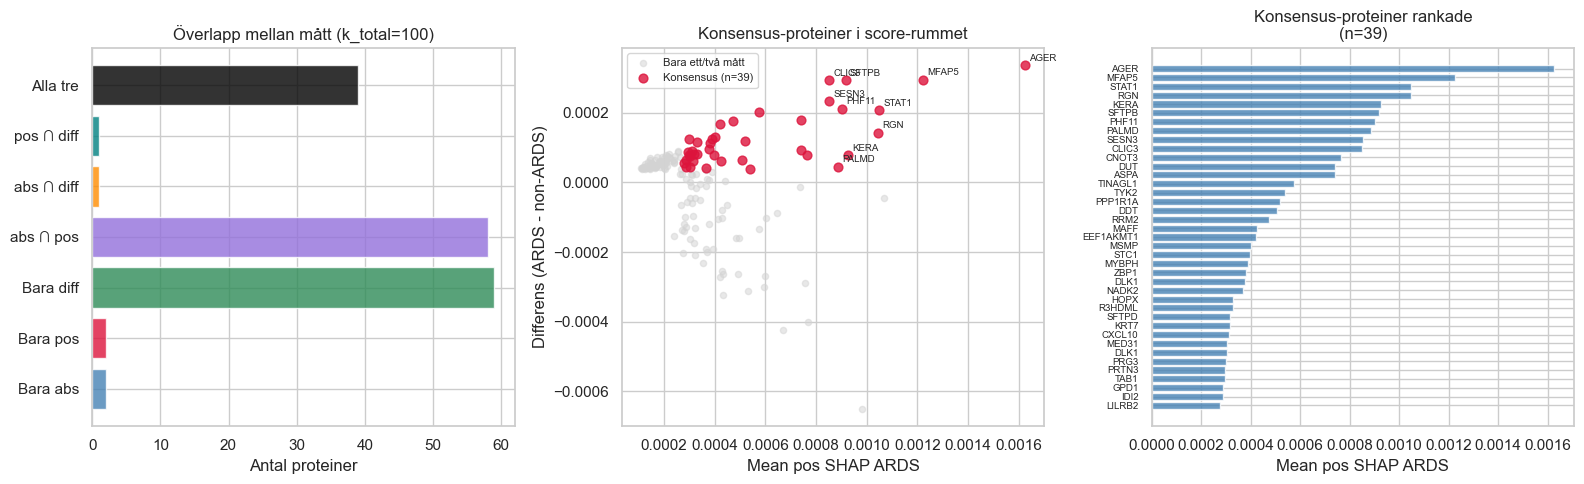

: 

In [ ]:
# ── Visualisera konsensus-proteinerna ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Venn-liknande bar — hur många i varje snitt
shap_ards   = shap_raw[y == 1]
shap_noards = shap_raw[y == 0]
mean_abs_ards = np.abs(shap_ards).mean(axis=0)
mean_pos_ards = np.where(shap_ards > 0, shap_ards, 0).mean(axis=0)
diff          = mean_abs_ards - np.abs(shap_noards).mean(axis=0)

top_abs  = set(np.argsort(-mean_abs_ards)[:K_TOTAL])
top_pos  = set(np.argsort(-mean_pos_ards)[:K_TOTAL])
top_diff = set(np.argsort(-diff)[:K_TOTAL])

ax = axes[0]
categories = [
    "Bara abs",
    "Bara pos",
    "Bara diff",
    "abs ∩ pos",
    "abs ∩ diff",
    "pos ∩ diff",
    "Alla tre",
]
values = [
    len(top_abs - top_pos - top_diff),
    len(top_pos - top_abs - top_diff),
    len(top_diff - top_abs - top_pos),
    len(top_abs & top_pos - top_diff),
    len(top_abs & top_diff - top_pos),
    len(top_pos & top_diff - top_abs),
    len(top_abs & top_pos & top_diff),
]
colors = ["steelblue", "crimson", "seagreen",
          "mediumpurple", "darkorange", "teal", "black"]
ax.barh(categories, values, color=colors, alpha=0.8)
ax.set_xlabel("Antal proteiner")
ax.set_title(f"Överlapp mellan mått (k_total={K_TOTAL})")

# 2. Scatter mean pos vs diff för konsensus-proteiner
ax = axes[1]
all_idx = list(top_abs | top_pos | top_diff)
in_consensus = np.array([i in set(consensus_list) for i in all_idx])

ax.scatter(
    mean_pos_ards[all_idx][~in_consensus],
    diff[all_idx][~in_consensus],
    c="lightgray", s=20, alpha=0.5, label="Bara ett/två mått"
)
ax.scatter(
    mean_pos_ards[all_idx][in_consensus],
    diff[all_idx][in_consensus],
    c="crimson", s=40, alpha=0.8, label=f"Konsensus (n={len(consensus_list)})"
)
for i in consensus_list[:10]:
    symbol = annot[annot["PROBEID"] == protein_cols[i].replace("seq.","").replace(".","-")]["SYMBOL"]
    label  = symbol.values[0] if len(symbol) > 0 else "?"
    ax.annotate(label, (mean_pos_ards[i], diff[i]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Mean pos SHAP ARDS")
ax.set_ylabel("Differens (ARDS - non-ARDS)")
ax.set_title("Konsensus-proteiner i score-rummet")
ax.legend(fontsize=8)

# 3. Rankad mean pos SHAP för konsensus-proteiner
ax = axes[2]
scores_consensus = [mean_pos_ards[i] for i in consensus_list]
symbols_consensus = []
for i in consensus_list:
    hit = annot[annot["PROBEID"] == protein_cols[i].replace("seq.","").replace(".","-")]
    symbols_consensus.append(hit["SYMBOL"].values[0] if len(hit) > 0 else "?")

ax.barh(range(len(scores_consensus)), scores_consensus[::-1],
        color="steelblue", alpha=0.8)
ax.set_yticks(range(len(scores_consensus)))
ax.set_yticklabels(symbols_consensus[::-1], fontsize=7)
ax.set_xlabel("Mean pos SHAP ARDS")
ax.set_title(f"Konsensus-proteiner rankade\n(n={len(consensus_list)})")

plt.tight_layout()
plt.show()

max_k=  100: k=31
max_k=  200: k=37
max_k=  300: k=46
max_k=  500: k=66
max_k= 1000: k=118
max_k= 2000: k=228


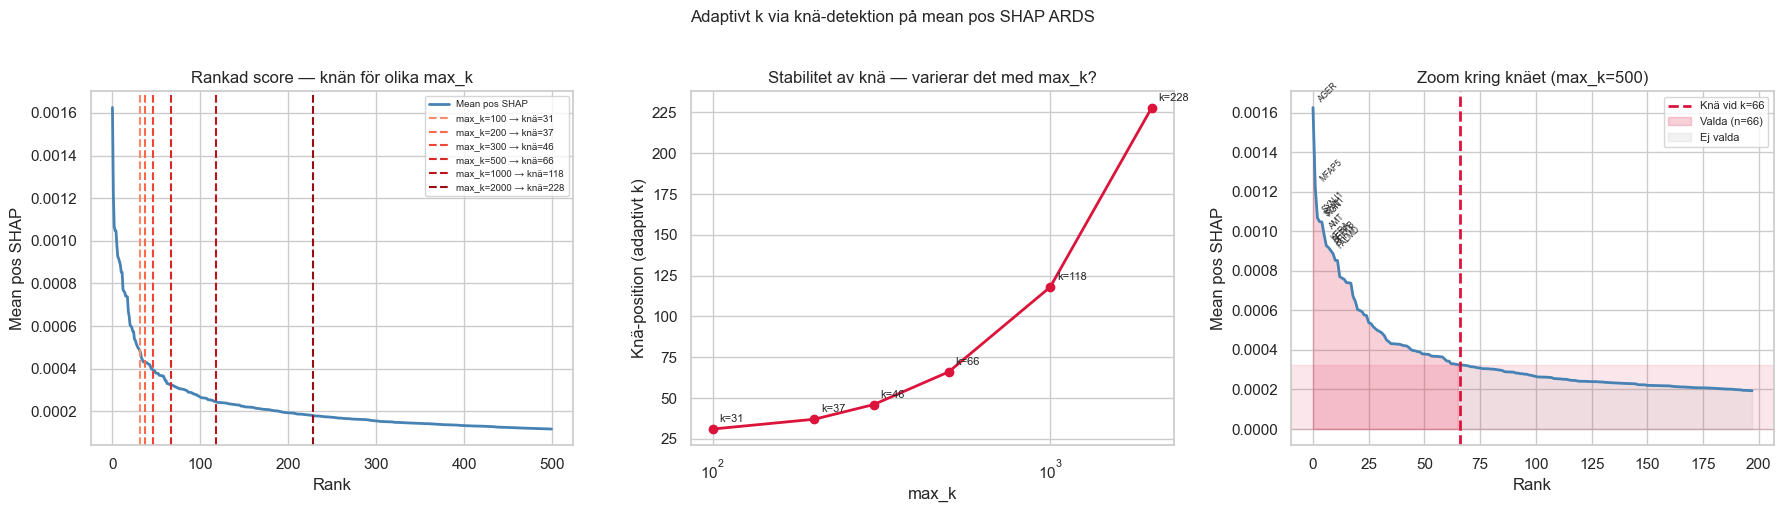

: 

In [ ]:
from kneed import KneeLocator

shap_ards     = shap_raw[y == 1]
mean_pos_ards = np.where(shap_ards > 0, shap_ards, 0).mean(axis=0)

def adaptive_k_knee(scores, max_k=500):
    scores_sorted = np.sort(scores)[::-1]
    scores_sorted = scores_sorted[scores_sorted > 0]
    n = min(len(scores_sorted), max_k)
    knee = KneeLocator(
        range(n), scores_sorted[:n],
        curve="convex", direction="decreasing",
        interp_method="polynomial",
    )
    return knee.knee if knee.knee else n

# ── Sensitivitet ──────────────────────────────────────────────────────────────
max_ks  = [100, 200, 300, 500, 1000, 2000]
knees   = [adaptive_k_knee(mean_pos_ards, max_k=m) for m in max_ks]

for m, k in zip(max_ks, knees):
    print(f"max_k={m:5d}: k={k}")

# ── Visualisera ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scores_sorted = np.sort(mean_pos_ards)[::-1]
scores_nz     = scores_sorted[scores_sorted > 0]

# Plot 1: Rankad kurva med knän för olika max_k
ax = axes[0]
ax.plot(scores_nz[:500], color="steelblue", lw=2, label="Mean pos SHAP")
colors_k = plt.cm.Reds(np.linspace(0.4, 0.9, len(max_ks)))
for (m, k), col in zip(zip(max_ks, knees), colors_k):
    if k and k < 500:
        ax.axvline(k, color=col, lw=1.5, linestyle="--",
                   label=f"max_k={m} → knä={k}")
ax.set_xlabel("Rank")
ax.set_ylabel("Mean pos SHAP")
ax.set_title("Rankad score — knän för olika max_k")
ax.legend(fontsize=7)

# Plot 2: Knä-värde vs max_k — är det stabilt?
ax = axes[1]
ax.plot(max_ks, knees, marker="o", color="crimson", lw=2)
ax.set_xlabel("max_k")
ax.set_ylabel("Knä-position (adaptivt k)")
ax.set_title("Stabilitet av knä — varierar det med max_k?")
ax.set_xscale("log")
for m, k in zip(max_ks, knees):
    ax.annotate(f"k={k}", (m, k), fontsize=8,
                xytext=(5, 5), textcoords="offset points")

# Plot 3: Zooma in kring knäet för bästa max_k
best_max_k = 500
k_best     = adaptive_k_knee(mean_pos_ards, max_k=best_max_k)
zoom_range = min(k_best * 3, best_max_k)

ax = axes[2]
ax.plot(scores_nz[:zoom_range], color="steelblue", lw=2)
if k_best:
    ax.axvline(k_best, color="crimson", lw=2, linestyle="--",
               label=f"Knä vid k={k_best}")
    ax.axhspan(0, scores_nz[k_best] if k_best < len(scores_nz) else 0,
               alpha=0.1, color="crimson")
    # Markera proteiner över knäet
    ax.fill_between(range(k_best), scores_nz[:k_best],
                    alpha=0.2, color="crimson", label=f"Valda (n={k_best})")
    ax.fill_between(range(k_best, zoom_range),
                    scores_nz[k_best:zoom_range],
                    alpha=0.1, color="gray", label="Ej valda")

# Annotera topp-10 proteiner
for rank in range(min(10, k_best if k_best else 10)):
    prot_i   = np.argsort(-mean_pos_ards)[rank]
    probe_id = protein_cols[prot_i].replace("seq.", "").replace(".", "-")
    hit      = annot[annot["PROBEID"] == probe_id]
    symbol   = hit["SYMBOL"].values[0] if len(hit) > 0 else "?"
    ax.annotate(symbol, (rank, scores_nz[rank]),
                fontsize=6, rotation=45, ha="left",
                xytext=(2, 4), textcoords="offset points")

ax.set_xlabel("Rank")
ax.set_ylabel("Mean pos SHAP")
ax.set_title(f"Zoom kring knäet (max_k={best_max_k})")
ax.legend(fontsize=8)

plt.suptitle("Adaptivt k via knä-detektion på mean pos SHAP ARDS",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

=== Signed mean SHAP per protein ===
ARDS    — mean: 0.000018, std: 0.000053, min: -0.000019, max: 0.001445
nonARDS — mean: -0.000042, std: 0.000047, min: -0.000990, max: -0.000001

=== Absolut magnitud per protein ===
ARDS    — mean |SHAP|: 0.000020
nonARDS — mean |SHAP|: 0.000042


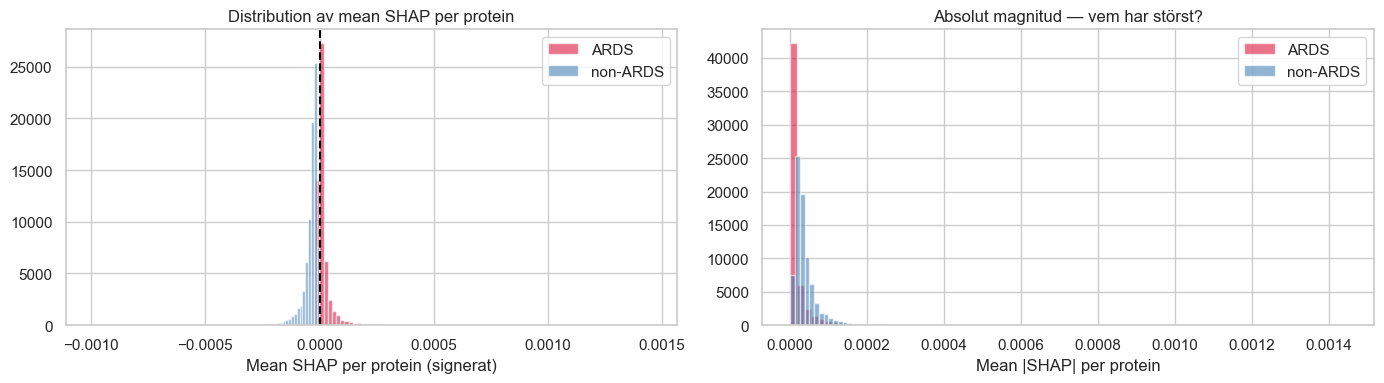

: 

In [ ]:
shap_ards_mean_signed   = shap_raw[y == 1].mean(axis=0)
shap_noards_mean_signed = shap_raw[y == 0].mean(axis=0)

print("=== Signed mean SHAP per protein ===")
print(f"ARDS    — mean: {shap_ards_mean_signed.mean():.6f}, "
      f"std: {shap_ards_mean_signed.std():.6f}, "
      f"min: {shap_ards_mean_signed.min():.6f}, "
      f"max: {shap_ards_mean_signed.max():.6f}")
print(f"nonARDS — mean: {shap_noards_mean_signed.mean():.6f}, "
      f"std: {shap_noards_mean_signed.std():.6f}, "
      f"min: {shap_noards_mean_signed.min():.6f}, "
      f"max: {shap_noards_mean_signed.max():.6f}")

print("\n=== Absolut magnitud per protein ===")
print(f"ARDS    — mean |SHAP|: {np.abs(shap_ards_mean_signed).mean():.6f}")
print(f"nonARDS — mean |SHAP|: {np.abs(shap_noards_mean_signed).mean():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(shap_ards_mean_signed, bins=80, alpha=0.6, 
        color="crimson", label="ARDS", density=True)
ax.hist(shap_noards_mean_signed, bins=80, alpha=0.6,
        color="steelblue", label="non-ARDS", density=True)
ax.axvline(0, color="black", lw=1.5, linestyle="--")
ax.set_xlabel("Mean SHAP per protein (signerat)")
ax.set_title("Distribution av mean SHAP per protein")
ax.legend()

ax = axes[1]
ax.hist(np.abs(shap_ards_mean_signed), bins=80, alpha=0.6,
        color="crimson", label="ARDS", density=True)
ax.hist(np.abs(shap_noards_mean_signed), bins=80, alpha=0.6,
        color="steelblue", label="non-ARDS", density=True)
ax.set_xlabel("Mean |SHAP| per protein")
ax.set_title("Absolut magnitud — vem har störst?")
ax.legend()

plt.tight_layout()
plt.show()